In [50]:
!pip install pyreadstat

##Mounting from Google Drive

In [51]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
mainPath = "/content/drive/MyDrive/PSM 691 DATA/CSV_DATASETS/"
results_path = mainPath + "Regression_Results/"
import os
os.makedirs(results_path, exist_ok=True)
print(f"Regression results will be saved to: {results_path}")

Regression results will be saved to: /content/drive/MyDrive/PSM 691 DATA/CSV_DATASETS/Regression_Results/


## Importing Data for 2020 to 2024

In [54]:
import pandas as pd
mainPath = "/content/drive/MyDrive/CSV_FILES_PSM691/"
df2024 = pd.read_csv(mainPath + "2024.csv")
df2023 = pd.read_csv(mainPath + "2023.csv")
df2022 = pd.read_csv(mainPath + "2022.csv")
df2021 = pd.read_csv(mainPath + "2021.csv")
df2020 = pd.read_csv(mainPath + "2020.csv")

/tmp/ipykernel_2486/2938726110.py:3: DtypeWarning: Columns (88,301,302,303,304,305,306,307,308,1232,1233,1234,1235,1236,1237,1238,1239,1240,1241,1242,1243,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,2398,2399,2400,2401,2402,2403,2404,2405,2406,2407,2408,2409,2410,2411,2412,2413,2414,2415,2416,2417,2418,2419,2420,2421,2488,2489,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500,2501,2502,2503,2504,2505,2512,2514,2515,2518) have mixed types. Specify dtype option on import or set low_memory=False.
  df2024 = pd.read_csv(mainPath + "2024.csv")
/tmp/ipykernel_2486/2938726110.py:4: DtypeWarning: Columns (2635) have mixed types. Specify dtype option on import or set low_memory=False.
  df2023 = pd.read_csv(mainPath + "2023.csv")
/tmp/ipykernel_2486/2938726110.py:5: DtypeWarning: Columns (1255,1257,1258,1259,1260,1261,1262,1263,1264,1265,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904,2066,2068) have mi

## Exploratory Data Analysis

### Add Year Column to DataFrames

In [55]:
dataFrames = [df2020, df2021, df2022, df2023, df2024]
for i, data in enumerate(dataFrames):
  data['YEAR'] = '202'+ str(i)

# Checking Number of Rows and Columns in Dataset

In [56]:
dataFrames = [df2020, df2021, df2022, df2023, df2024]
for i,data in enumerate(dataFrames):
  print(f'Year 202{i}: {data.shape[0]} rows and {data.shape[1]} columns.')

Year 2020: 32893 rows and 2891 columns.
Year 2021: 58034 rows and 2996 columns.
Year 2022: 59069 rows and 2654 columns.
Year 2023: 4448 rows and 2637 columns.
Year 2024: 58633 rows and 2633 columns.


### Rename Columns in DataFrame

In [57]:
weight_map = {
    2020: 'ANALWTQ1Q4_C',
    2021: 'ANALWT2_C',
    2022: 'ANALWT2_C',
    2023: 'ANALWT2_C',
    2024: 'ANALWT2_C'
}

for year, df in zip(
    [2020, 2021, 2022, 2023, 2024],
    [df2020, df2021, df2022, df2023, df2024]
):
    df.columns = df.columns.str.strip()
    print(year, weight_map[year] in df.columns)

# Renaming columns in 2020 dataset to match with other years.
df2020 = df2020.rename(columns={'AGE2':'AGE3','ANALWTQ1Q4_C': 'ANALWT2_C','AMIYR_U':'AMIPY','SMIYR_U': 'SMIPY','AMDEYR':'IRAMDEYR','AMDEIMP':'IRAMDEIMP'})

2020 True
2021 True
2022 True
2023 True
2024 True


In [58]:
df2020 = df2020.rename(columns={'AGE2':'AGE3','ANALWTQ1Q4_C': 'ANALWT2_C','AMIYR_U':'AMIPY','SMIYR_U': 'SMIPY','AMDEYR':'IRAMDEYR','AMDEIMP':'IRAMDEIMP'})

In [59]:
colsPresentForAllDataFrames = ['YEAR','COUTYP4','AGE3','IRSEX','ANALWT2_C','NEWRACE2','AMIPY','SMIPY','IRAMDEYR','IRAMDEIMP','HPUSETOB','HPUSEALC','HPUSEDRG','POVERTY3','IRFAMIN3']

In [60]:
df2020 = df2020[colsPresentForAllDataFrames]
df2021 = df2021[colsPresentForAllDataFrames]
df2022 = df2022[colsPresentForAllDataFrames]
df2023 = df2023[colsPresentForAllDataFrames]
df2024 = df2024[colsPresentForAllDataFrames]

print(df2020.shape[1])
df2022.head()

15


,YEAR,COUTYP4,AGE3,IRSEX,ANALWT2_C,NEWRACE2,AMIPY,SMIPY,IRAMDEYR,IRAMDEIMP,HPUSETOB,HPUSEALC,HPUSEDRG,POVERTY3,IRFAMIN3
0,2022,1 - Large Metro,6 - Respondent is 24 or 25 years old,1 - Male,298.004021,7 - Hispanic,0 - No Past Yr Any Mental Illness,0 - No Past Year SMI,0 - No,0 - No,99 - LEGITIMATE SKIP,99 - LEGITIMATE SKIP,99 - LEGITIMATE SKIP,3 - Income More Than 2X Fed Pov Thresh,"5 - $40,000 - $49,999"
1,2022,2 - Small Metro,9 - Respondent is between 35 and 49 years old,2 - Female,2292.377696,2 - NonHisp Black/Afr Am,0 - No Past Yr Any Mental Illness,0 - No Past Year SMI,0 - No,0 - No,1 - Yes,1 - Yes,1 - Yes,3 - Income More Than 2X Fed Pov Thresh,"6 - $50,000 - $74,999"
2,2022,1 - Large Metro,6 - Respondent is 24 or 25 years old,2 - Female,216.604339,1 - NonHisp White,0 - No Past Yr Any Mental Illness,0 - No Past Year SMI,0 - No,0 - No,2 - No,1 - Yes,1 - Yes,3 - Income More Than 2X Fed Pov Thresh,"7 - $75,000 or more"
3,2022,1 - Large Metro,7 - Respondent is between 26 and 29 years old,1 - Male,13828.218374,5 - NonHisp Asian,0 - No Past Yr Any Mental Illness,0 - No Past Year SMI,0 - No,0 - No,1 - Yes,1 - Yes,2 - No,3 - Income More Than 2X Fed Pov Thresh,"7 - $75,000 or more"
4,2022,2 - Small Metro,10 - Respondent is between 50 and 64 years old,2 - Female,6282.612060,1 - NonHisp White,1 - Past Year Any Mental Illness,0 - No Past Year SMI,0 - No,0 - No,1 - Yes,1 - Yes,2 - No,3 - Income More Than 2X Fed Pov Thresh,"6 - $50,000 - $74,999"


In [61]:
dataFrames = [df2020, df2021, df2022, df2023, df2024]
mergedData = pd.concat(dataFrames).reset_index(drop=True)

In [62]:
# Number of Rows and Columns in Merged Data
mergedData.shape

(213077, 15)

In [63]:
mergedData = mergedData.rename(columns={
    'ANALWT2_C': 'SurveyWeights',
    'IRSEX': 'Sex',
    'COUTYP4': 'CountyType',
    'AGE3': 'AgeCategory',
    'NEWRACE2': 'Race',
    'AMIPY' : 'AnyMentalIllnessPastYear',
    'SMIPY' : 'SeriousMentalIllnessPastYear',
    'IRAMDEYR': 'MajorDepressiveEpisodePastYear',
    'IRAMDEIMP' : 'MajorDepressiveEpisodeWithSevereRoleImpairment',
    'HPUSETOB': 'TobaccoUseInPastYear',
    'HPUSEALC': 'AlcoholUseInPastYear',
    'HPUSEDRG': 'DrugUseInPastYear',
    'POVERTY3' : 'HouseholdPovertyStatus',
    'IRFAMIN3': 'FamilyIncome',
    'YEAR' : 'YEAR'
})

In [64]:
# Checking for Missing Values and Unique Values in each Columns
for i in mergedData.columns:
  print(f'"{i}" has {mergedData[i].isna().sum()} missing values and {mergedData[i].nunique()} unique values')
  print(f'These are the unique values: {list(mergedData[i].unique())}')
  print('--'*50)

"YEAR" has 0 missing values and 5 unique values
These are the unique values: ['2020', '2021', '2022', '2023', '2024']
----------------------------------------------------------------------------------------------------
"CountyType" has 0 missing values and 6 unique values
These are the unique values: ['3 - Nonmetro', '2 - Small Metro', '1 - Large Metro', 2, 3, 1]
----------------------------------------------------------------------------------------------------
"AgeCategory" has 0 missing values and 39 unique values
These are the unique values: ['15 - Respondent is between 35 and 49 years old', '14 - Respondent is between 30 and 34 years old', '3 - Respondent is 14 years old', '7 - Respondent is 18 years old', '13 - Respondent is between 26 and 29 years old', '12 - Respondent is 24 or 25 years old', '16 - Respondent is between 50 and 64 years old', '10 - Respondent is 21 years old', '17 - Respondent is 65 years old or older', '5 - Respondent is 16 years old', '8 - Respondent is 19 yea

## Handling Missing Value Codes


In [65]:
import numpy as np

missing_codes = [85, 94, 97, 98, 99]

cols_to_clean = [
    'AnyMentalIllnessPastYear',
    'SeriousMentalIllnessPastYear',
    'MajorDepressiveEpisodePastYear',
    'MajorDepressiveEpisodeWithSevereRoleImpairment',
    'TobaccoUseInPastYear',
    'AlcoholUseInPastYear',
    'DrugUseInPastYear',
    'HouseholdPovertyStatus',
    'AgeCategory'
]

for col in cols_to_clean:
    mergedData[col] = mergedData[col].replace(missing_codes, np.nan)

## Data Cleaning and Standardization

In [66]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os

# 1. KEEP ONLY RELEVANT COLUMNS

work_df = mergedData[[
    'YEAR',
    'CountyType',
    'AgeCategory',
    'Sex',
    'SurveyWeights',
    'Race',
    'HouseholdPovertyStatus',
    'FamilyIncome',
    'AnyMentalIllnessPastYear',
    'SeriousMentalIllnessPastYear',
    'MajorDepressiveEpisodePastYear',
    'MajorDepressiveEpisodeWithSevereRoleImpairment',
    'TobaccoUseInPastYear',
    'AlcoholUseInPastYear',
    'DrugUseInPastYear'
]].copy()

print("Starting shape:", work_df.shape)


# 2. HELPER FUNCTION: EXTRACT NUMERIC CODE

def extract_code(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip()
    if s == "":
        return np.nan

    match = re.match(r"^(-?\d+(\.\d+)?)", s)
    if match:
        return float(match.group(1))

    return np.nan


# 3. CREATE STANDARDIZED CODE COLUMNS
cols_to_standardize = [
    'YEAR',
    'CountyType',
    'AgeCategory',
    'Sex',
    'SurveyWeights',
    'Race',
    'HouseholdPovertyStatus',
    'FamilyIncome',
    'AnyMentalIllnessPastYear',
    'SeriousMentalIllnessPastYear',
    'MajorDepressiveEpisodePastYear',
    'MajorDepressiveEpisodeWithSevereRoleImpairment',
    'TobaccoUseInPastYear',
    'AlcoholUseInPastYear',
    'DrugUseInPastYear'
]

for col in cols_to_standardize:
    work_df[col + '_code'] = work_df[col].apply(extract_code)

int_code_cols = [
    'YEAR_code',
    'CountyType_code',
    'AgeCategory_code',
    'Sex_code',
    'Race_code',
    'HouseholdPovertyStatus_code',
    'FamilyIncome_code',
    'AnyMentalIllnessPastYear_code',
    'SeriousMentalIllnessPastYear_code',
    'MajorDepressiveEpisodePastYear_code',
    'MajorDepressiveEpisodeWithSevereRoleImpairment_code',
    'TobaccoUseInPastYear_code',
    'AlcoholUseInPastYear_code',
    'DrugUseInPastYear_code'
]

for col in int_code_cols:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce').astype('Int64')

work_df['SurveyWeights_code'] = pd.to_numeric(work_df['SurveyWeights_code'], errors='coerce')


# 4. HARMONIZE YEAR
work_df['YEAR_clean'] = work_df['YEAR_code'].astype('Int64')


# 5. HARMONIZE COUNTY TYPE

county_map = {
    1: 'Large Metro',
    2: 'Small Metro',
    3: 'Nonmetro'
}
work_df['CountyType_clean'] = work_df['CountyType_code'].map(county_map)

# 6. HARMONIZE SEX

sex_map = {
    1: 'Male',
    2: 'Female'
}
work_df['Sex_clean'] = work_df['Sex_code'].map(sex_map)

# 7. HARMONIZE RACE

race_map = {
    1: 'Non-Hispanic White',
    2: 'Non-Hispanic Black',
    3: 'Non-Hispanic Native American/AK Native',
    4: 'Non-Hispanic Native Hawaiian/Pacific Islander',
    5: 'Non-Hispanic Asian',
    6: 'Non-Hispanic More Than One Race',
    7: 'Hispanic'
}
work_df['Race_clean'] = work_df['Race_code'].map(race_map)



# 8. HARMONIZE POVERTY STATUS
poverty_map = {
    1: 'Living in Poverty',
    2: 'Income up to 2x FPL',
    3: 'Income > 2x FPL'
}
work_df['Poverty_clean'] = work_df['HouseholdPovertyStatus_code'].map(poverty_map)


# 9. HARMONIZE FAMILY INCOME
family_income_map = {
    1: 'Less than $10,000',
    2: '$10,000-$19,999',
    3: '$20,000-$29,999',
    4: '$30,000-$39,999',
    5: '$40,000-$49,999',
    6: '$50,000-$74,999',
    7: '$75,000 or more'
}
work_df['FamilyIncome_clean'] = work_df['FamilyIncome_code'].map(family_income_map)


# 10. HARMONIZE AGE ACROSS YEARS

def harmonize_age(year_code, age_code):
    if pd.isna(year_code) or pd.isna(age_code):
        return np.nan

    year_code = int(year_code)
    age_code = int(age_code)

    if year_code == 2020:
        if age_code in [7, 8, 9, 10, 11, 12]:
            return '18-25'
        elif age_code in [13, 14]:
            return '26-34'
        elif age_code == 15:
            return '35-49'
        elif age_code == 16:
            return '50-64'
        elif age_code == 17:
            return '65+'
        else:
            return np.nan
    else:
        if age_code in [4, 5, 6]:
            return '18-25'
        elif age_code in [7, 8]:
            return '26-34'
        elif age_code == 9:
            return '35-49'
        elif age_code == 10:
            return '50-64'
        elif age_code == 11:
            return '65+'
        else:
            return np.nan

work_df['AgeGroup_clean'] = work_df.apply(
    lambda row: harmonize_age(row['YEAR_code'], row['AgeCategory_code']),
    axis=1
)


# 11. CLEAN SURVEY WEIGHTS
work_df['Weight_clean'] = pd.to_numeric(work_df['SurveyWeights_code'], errors='coerce')
work_df.loc[work_df['Weight_clean'] <= 0, 'Weight_clean'] = np.nan


# 12. CLEAN OUTCOMES
def clean_binary_01(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    if x in [0, 1]:
        return x
    return np.nan

def clean_mde_style(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    if x == 1:
        return 1
    elif x in [0, 2]:
        return 0
    return np.nan

work_df['AMI'] = work_df['AnyMentalIllnessPastYear_code'].apply(clean_binary_01)
work_df['SMI'] = work_df['SeriousMentalIllnessPastYear_code'].apply(clean_binary_01)
work_df['MDE'] = work_df['MajorDepressiveEpisodePastYear_code'].apply(clean_mde_style)
work_df['MDE_SevereImpairment'] = work_df['MajorDepressiveEpisodeWithSevereRoleImpairment_code'].apply(clean_mde_style)



# 13. CLEAN SUBSTANCE-USE VARIABLES
invalid_substance_codes = [85, 94, 97, 98, 99]

def clean_substance(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    if x in invalid_substance_codes:
        return np.nan
    elif x == 1:
        return 1
    elif x == 2:
        return 0
    return np.nan

work_df['Tobacco'] = work_df['TobaccoUseInPastYear_code'].apply(clean_substance)
work_df['Alcohol'] = work_df['AlcoholUseInPastYear_code'].apply(clean_substance)
work_df['Drugs'] = work_df['DrugUseInPastYear_code'].apply(clean_substance)


# 14. LABELS FOR EDA / TABLES
yes_no_map = {1: 'Yes', 0: 'No'}

for col in ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment', 'Tobacco', 'Alcohol', 'Drugs']:
    work_df[col + '_label'] = work_df[col].map(yes_no_map)


# =========================================================
# 15. CREATE FINAL STANDARDIZED ANALYSIS DATASET
analysis_df = work_df[[
    'YEAR_clean',
    'Weight_clean',
    'CountyType_clean',
    'AgeGroup_clean',
    'Sex_clean',
    'Race_clean',
    'Poverty_clean',
    'FamilyIncome_clean',
    'AMI',
    'SMI',
    'MDE',
    'MDE_SevereImpairment',
    'Tobacco',
    'Alcohol',
    'Drugs'
]].copy()

analysis_df = analysis_df.dropna().copy()

analysis_df = analysis_df.rename(columns={
    'YEAR_clean': 'YEAR',
    'Weight_clean': 'SurveyWeight',
    'CountyType_clean': 'CountyType',
    'AgeGroup_clean': 'AgeGroup',
    'Sex_clean': 'Sex',
    'Race_clean': 'Race',
    'Poverty_clean': 'Poverty',
    'FamilyIncome_clean': 'FamilyIncome'
})


# =========================================================
# 16. SET CATEGORY ORDER
# =========================================================
analysis_df['AgeGroup'] = pd.Categorical(
    analysis_df['AgeGroup'],
    categories=['18-25', '26-34', '35-49', '50-64', '65+'],
    ordered=True
)

analysis_df['CountyType'] = pd.Categorical(
    analysis_df['CountyType'],
    categories=['Large Metro', 'Small Metro', 'Nonmetro'],
    ordered=True
)

analysis_df['Poverty'] = pd.Categorical(
    analysis_df['Poverty'],
    categories=['Income > 2x FPL', 'Income up to 2x FPL', 'Living in Poverty'],
    ordered=True
)

analysis_df['FamilyIncome'] = pd.Categorical(
    analysis_df['FamilyIncome'],
    categories=[
        'Less than $10,000',
        '$10,000-$19,999',
        '$20,000-$29,999',
        '$30,000-$39,999',
        '$40,000-$49,999',
        '$50,000-$74,999',
        '$75,000 or more'
    ],
    ordered=True
)


# 17. POST-CLEANING AUDIT

print("\n================ POST-CLEANING AUDIT ==============\n")
print("Final shape:", analysis_df.shape)

print("\nMissing values:")
print(analysis_df.isna().sum())

for col in analysis_df.columns:
    print(f"\n===== {col} =====")
    if str(analysis_df[col].dtype) == 'category' or analysis_df[col].dtype == 'object':
        print(analysis_df[col].value_counts(dropna=False))
    else:
        if col == 'SurveyWeight':
            print(analysis_df[col].describe())
        else:
            print(analysis_df[col].value_counts(dropna=False).sort_index())


# 18. SAVE
output_csv_path = mainPath + "nsduh_2020_2024_final_standardized.csv"
analysis_df.to_csv(output_csv_path, index=False)

# Verify if the file was saved correctly
if os.path.exists(output_csv_path):
    print(f"\nSuccessfully saved standardized data to: {output_csv_path}")
else:
    print(f"\nERROR: Failed to save standardized data to: {output_csv_path}")
    print("Please check your Google Drive connection and permissions.")


Starting shape: (213077, 15)

================ POST-CLEANING AUDIT ==============

Final shape: (131426, 15)

Missing values:
YEAR                    0
SurveyWeight            0
CountyType              0
AgeGroup                0
Sex                     0
Race                    0
Poverty                 0
FamilyIncome            0
AMI                     0
SMI                     0
MDE                     0
MDE_SevereImpairment    0
Tobacco                 0
Alcohol                 0
Drugs                   0
dtype: int64

===== YEAR =====
YEAR
2020    20494
2021    36052
2022    36103
2023     2726
2024    36051
Name: count, dtype: Int64

===== SurveyWeight =====
count    131426.000000
mean       6287.997899
std       10307.918942
min           0.953663
25%         809.691500
50%        2591.391107
75%        7317.741378
max      222288.176600
Name: SurveyWeight, dtype: float64

===== CountyType =====
CountyType
Large Metro    59291
Small Metro    50865
Nonmetro       21270
Name: cou

In [67]:
analysis_df.head()

,YEAR,SurveyWeight,CountyType,AgeGroup,Sex,Race,Poverty,FamilyIncome,AMI,SMI,MDE,MDE_SevereImpairment,Tobacco,Alcohol,Drugs
0,2020,16186.579070,Nonmetro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$75,000 or more",0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,2020,16809.072850,Small Metro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$50,000-$74,999",1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,2020,1379.866862,Large Metro,26-34,Female,Non-Hispanic More Than One Race,Income > 2x FPL,"$30,000-$39,999",1.0,0.0,0.0,0.0,1.0,1.0,1.0
3,2020,422.776340,Large Metro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$75,000 or more",0.0,0.0,0.0,0.0,1.0,1.0,1.0
5,2020,2529.748991,Small Metro,18-25,Female,Hispanic,Income > 2x FPL,"$40,000-$49,999",0.0,0.0,0.0,0.0,1.0,1.0,1.0


##

#**Visualization of Substance Use and Mental Health Trends for Unweighted**





## Setup and output folder

In [68]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create folder for saved visuals
fig_path = mainPath + "EDA_Figures/"
os.makedirs(fig_path, exist_ok=True)

print("Figures will be saved to:", fig_path)

# Plot defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

Figures will be saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/


### 1.Overall Prevalence of Mental Health Outcomes

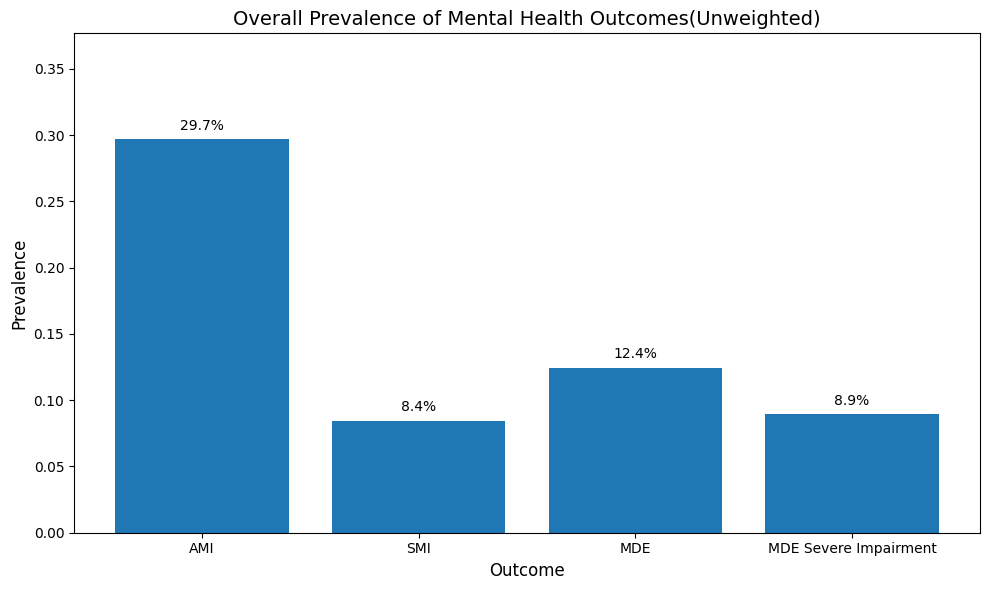

,Outcome,Prevalence
0,AMI,0.296768
1,SMI,0.084451
2,MDE,0.124367
3,MDE Severe Impairment,0.089465


In [69]:
mh_cols = ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment']
mh_labels = ['AMI', 'SMI', 'MDE', 'MDE Severe Impairment']
mh_vals = [analysis_df[col].mean() for col in mh_cols]

plt.figure()
bars = plt.bar(mh_labels, mh_vals)
plt.title("Overall Prevalence of Mental Health Outcomes(Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Outcome")

for bar, val in zip(bars, mh_vals):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.1%}",
             ha='center', va='bottom')

plt.ylim(0, max(mh_vals) + 0.08)
plt.tight_layout()
#plt.savefig(fig_path + "01_overall_mental_health_prevalence.png", dpi=300, bbox_inches='tight')
plt.show()

# Save summary table
mh_overall_df = pd.DataFrame({
    'Outcome': mh_labels,
    'Prevalence': mh_vals
})
mh_overall_df.to_csv(fig_path + "01_overall_mental_health_prevalence(Unweighted).csv", index=False)
mh_overall_df

### 2.Overall Prevalence of Substance Use

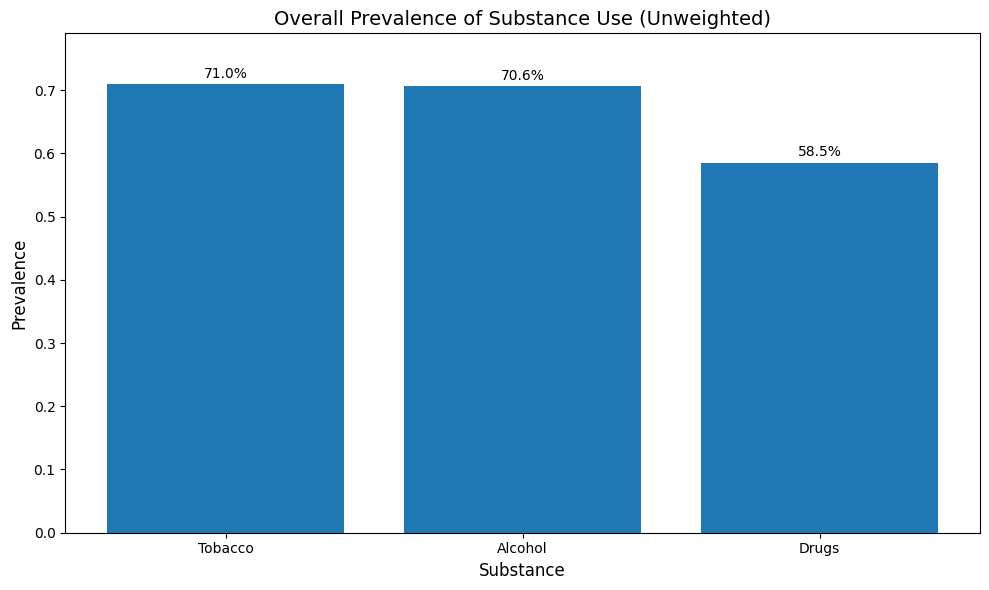

,Substance,Prevalence
0,Tobacco,0.709715
1,Alcohol,0.705698
2,Drugs,0.585447


In [70]:
sub_cols = ['Tobacco', 'Alcohol', 'Drugs']
sub_vals = [analysis_df[col].mean() for col in sub_cols]

plt.figure()
bars = plt.bar(sub_cols, sub_vals)
plt.title("Overall Prevalence of Substance Use (Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Substance")

for bar, val in zip(bars, sub_vals):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.1%}",
             ha='center', va='bottom')

plt.ylim(0, max(sub_vals) + 0.08)
plt.tight_layout()
#plt.savefig(fig_path + "02_overall_substance_use_prevalence.png", dpi=300, bbox_inches='tight')
plt.show()

# Save summary table
sub_overall_df = pd.DataFrame({
    'Substance': sub_cols,
    'Prevalence': sub_vals
})
sub_overall_df.to_csv(fig_path + "02_overall_substance_use_prevalence.csv", index=False)
sub_overall_df

### 3.Trends in Mental Health Outcomes overtime (2020–2024)

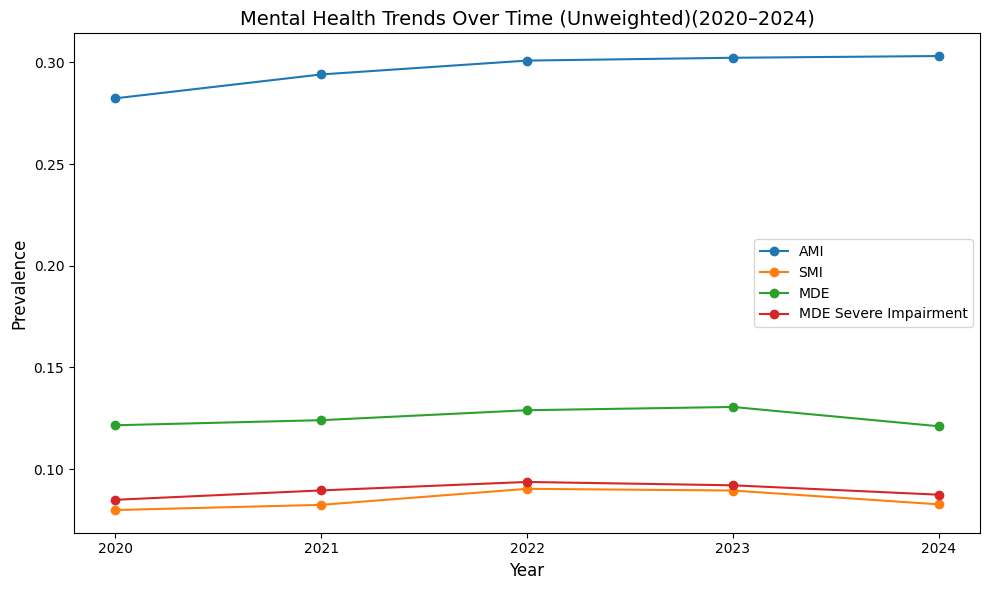

,AMI,SMI,MDE,MDE_SevereImpairment
YEAR,,,,
2020,0.282327,0.079926,0.121597,0.084952
2021,0.294075,0.082464,0.124099,0.089565
2022,0.300889,0.090353,0.128992,0.093732
2023,0.302274,0.089508,0.130594,0.092076
2024,0.303126,0.082716,0.121106,0.087459


In [72]:
mh_trends = analysis_df.groupby('YEAR')[['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment']].mean()

plt.figure()
for col, label in zip(['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment'],
                      ['AMI', 'SMI', 'MDE', 'MDE Severe Impairment']):
    plt.plot(mh_trends.index, mh_trends[col], marker='o', label=label)

plt.title("Mental Health Trends Over Time (Unweighted)(2020–2024)")
plt.ylabel("Prevalence")
plt.xlabel("Year")
plt.xticks(mh_trends.index)
plt.legend()
plt.tight_layout()
#plt.savefig(fig_path + "03_mental_health_trends_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

mh_trends.to_csv(fig_path + "03_mental_health_trends_over_time.csv")
mh_trends

### 4.Trends in Substance Use (2020–2024)

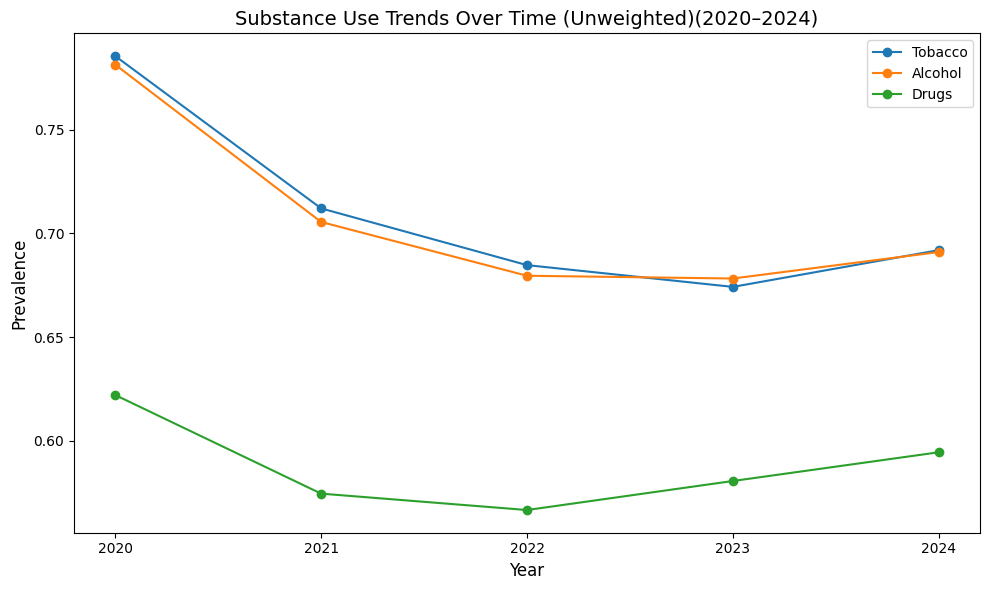

,Tobacco,Alcohol,Drugs
YEAR,,,
2020,0.785498,0.781351,0.622133
2021,0.712083,0.705536,0.574614
2022,0.684735,0.679611,0.566712
2023,0.674248,0.678283,0.580704
2024,0.691964,0.691049,0.594547


In [73]:
sub_trends = analysis_df.groupby('YEAR')[['Tobacco', 'Alcohol', 'Drugs']].mean()

plt.figure()
for col in ['Tobacco', 'Alcohol', 'Drugs']:
    plt.plot(sub_trends.index, sub_trends[col], marker='o', label=col)

plt.title("Substance Use Trends Over Time (Unweighted)(2020–2024)")
plt.ylabel("Prevalence")
plt.xlabel("Year")
plt.xticks(sub_trends.index)
plt.legend()
plt.tight_layout()
#plt.savefig(fig_path + "04_substance_use_trends_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

sub_trends.to_csv(fig_path + "04_substance_use_trends_over_time.csv")
sub_trends

###5.Demographic Differences in Mental Health by Sex

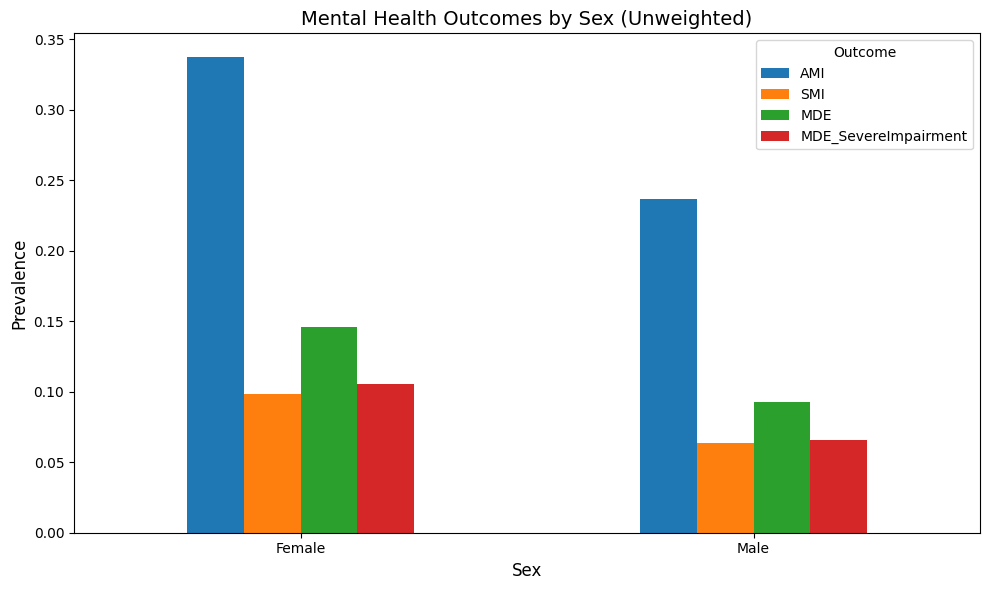

,AMI,SMI,MDE,MDE_SevereImpairment
Sex,,,,
Female,0.337338,0.098556,0.145894,0.105514
Male,0.236915,0.063641,0.092608,0.065788


In [74]:
sex_mh = analysis_df.groupby('Sex')[['AMI', 'SMI', 'MDE','MDE_SevereImpairment']].mean()

sex_mh.plot(kind='bar')
plt.title("Mental Health Outcomes by Sex (Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
#plt.savefig(fig_path + "06_mental_health_by_sex.png", dpi=300, bbox_inches='tight')
plt.show()

sex_mh.to_csv(fig_path + "06_mental_health_by_sex.csv")
sex_mh

###6.Mental Health Outcomes by Poverty Status

/tmp/ipykernel_2486/3844131158.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poverty_mh = analysis_df.groupby('Poverty')[['AMI', 'SMI', 'MDE','MDE_SevereImpairment']].mean()


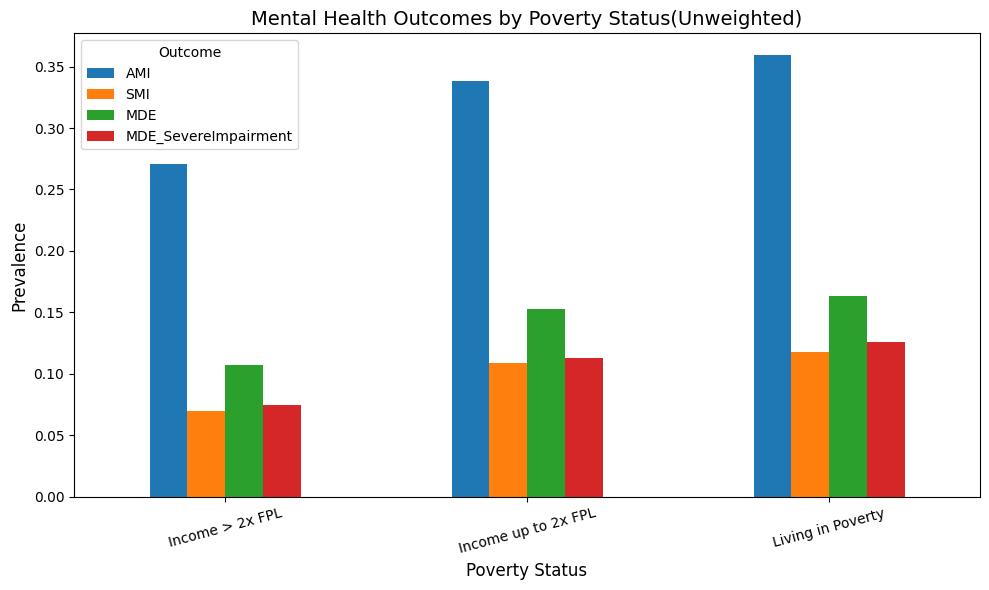

,AMI,SMI,MDE,MDE_SevereImpairment
Poverty,,,,
Income > 2x FPL,0.270685,0.069955,0.107441,0.074615
Income up to 2x FPL,0.338598,0.108886,0.152583,0.112698
Living in Poverty,0.359129,0.117719,0.163583,0.125649


In [75]:
poverty_mh = analysis_df.groupby('Poverty')[['AMI', 'SMI', 'MDE','MDE_SevereImpairment']].mean()

poverty_mh.plot(kind='bar')
plt.title("Mental Health Outcomes by Poverty Status(Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Poverty Status")
plt.xticks(rotation=15)
plt.legend(title="Outcome")
plt.tight_layout()
#plt.savefig(fig_path + "07_mental_health_by_poverty.png", dpi=300, bbox_inches='tight')
plt.show()

poverty_mh.to_csv(fig_path + "07_mental_health_by_poverty.csv")
poverty_mh

###7.Association Between Tobacco Use and Mental Health Outcomes

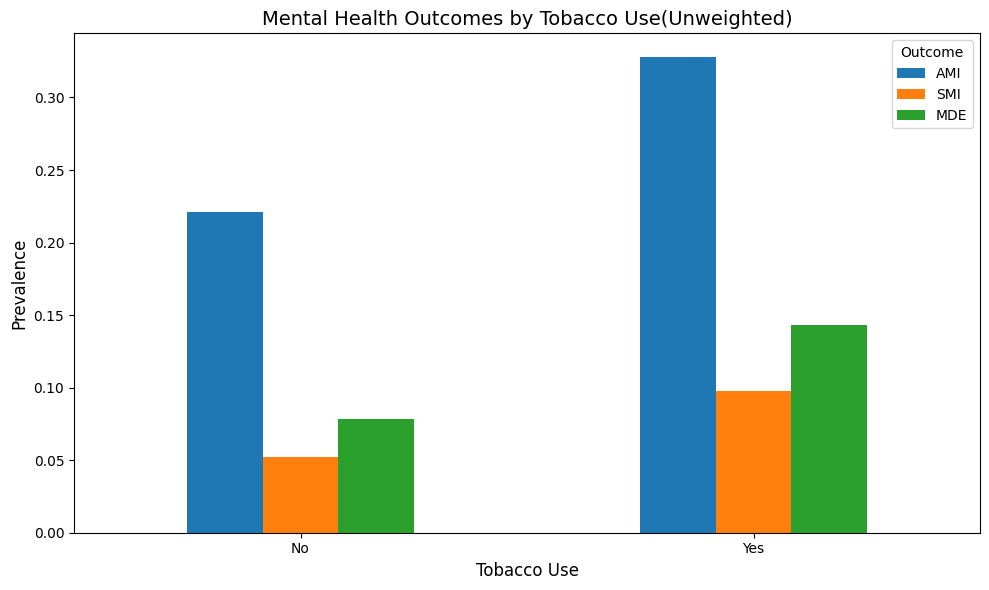

,AMI,SMI,MDE
No,0.220833,0.052004,0.078687
Yes,0.327826,0.097722,0.143050


In [76]:
tobacco_mh = analysis_df.groupby('Tobacco')[['AMI', 'SMI', 'MDE']].mean()
tobacco_mh.index = ['No', 'Yes']

tobacco_mh.plot(kind='bar')
plt.title("Mental Health Outcomes by Tobacco Use(Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Tobacco Use")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
#plt.savefig(fig_path + "10_mental_health_by_tobacco_use.png", dpi=300, bbox_inches='tight')
plt.show()

tobacco_mh.to_csv(fig_path + "10_mental_health_by_tobacco_use.csv")
tobacco_mh

###8.Association Between Alcohol Use and Mental Health Outcomes

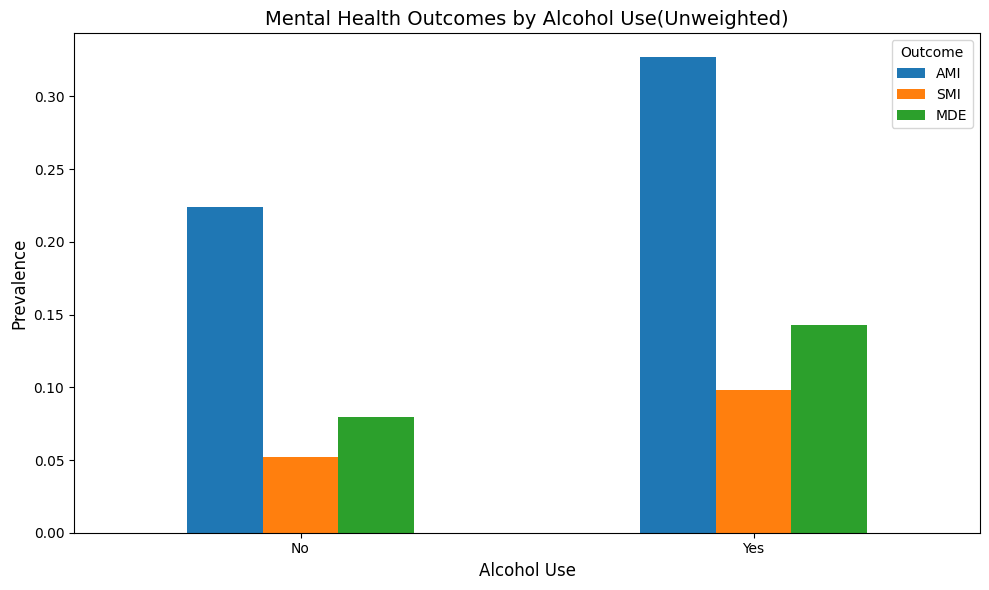

,AMI,SMI,MDE
No,0.224075,0.052251,0.079914
Yes,0.327083,0.097879,0.142905


In [77]:
alcohol_mh = analysis_df.groupby('Alcohol')[['AMI', 'SMI', 'MDE']].mean()
alcohol_mh.index = ['No', 'Yes']

alcohol_mh.plot(kind='bar')
plt.title("Mental Health Outcomes by Alcohol Use(Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Alcohol Use")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
#plt.savefig(fig_path + "11_mental_health_by_alcohol_use.png", dpi=300, bbox_inches='tight')
plt.show()

alcohol_mh.to_csv(fig_path + "11_mental_health_by_alcohol_use.csv")
alcohol_mh

###9.Association Between Drug Use and Mental Health Outcomes

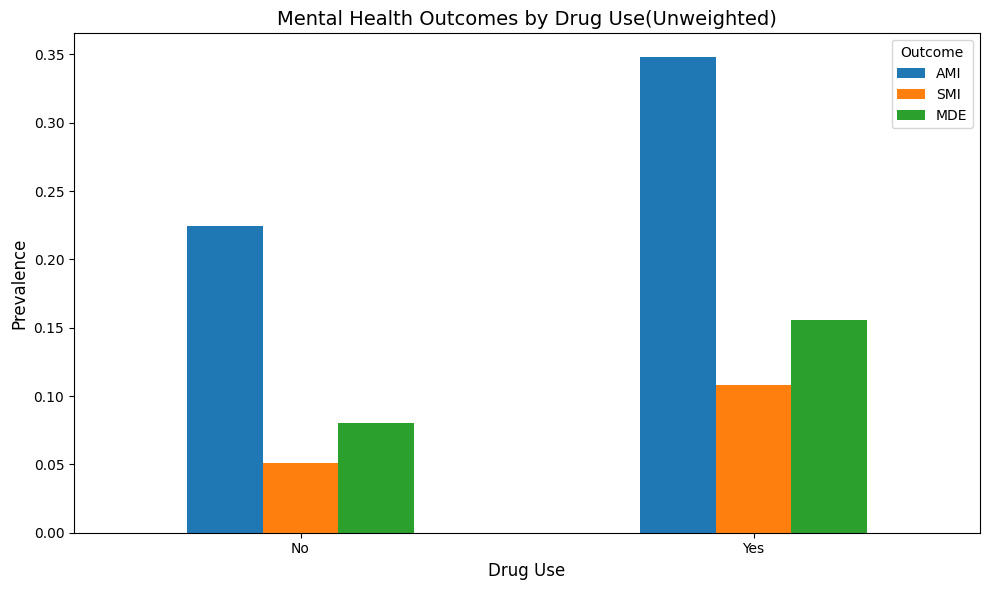

,AMI,SMI,MDE
No,0.224419,0.051117,0.080117
Yes,0.347998,0.108054,0.155700


In [78]:
drug_mh = analysis_df.groupby('Drugs')[['AMI', 'SMI', 'MDE']].mean()
drug_mh.index = ['No', 'Yes']

drug_mh.plot(kind='bar')
plt.title("Mental Health Outcomes by Drug Use(Unweighted)")
plt.ylabel("Prevalence")
plt.xlabel("Drug Use")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
#plt.savefig(fig_path + "12_mental_health_by_drug_use.png", dpi=300, bbox_inches='tight')
plt.show()

drug_mh.to_csv(fig_path + "12_mental_health_by_drug_use.csv")
drug_mh

#**Visualization of Substance Use and Mental Health Trends for Weighted**

In [79]:
import os
import matplotlib.pyplot as plt

def save_eda_figure(fig, file_name, result_type="Weighted"):
    """
    Saves a figure to a specific subfolder in Google Drive.
    result_type: 'Weighted'
    """
    # Construct the full path
    folder_path = os.path.join(mainPath, "EDA_Figures", result_type)

    # Create the directory if it doesn't exist
    os.makedirs(folder_path, exist_ok=True)

    # Save the figure
    save_path = os.path.join(folder_path, file_name)
    fig.savefig(save_path, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")

# --- Plot Defaults (Your existing code) ---
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12})

###1.Weighted vs Unweighted Mental Health Prevalence

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted_Vrs_Unweighted_Figures/Weighted vrs Unweighted Mental Health Prevalence.png


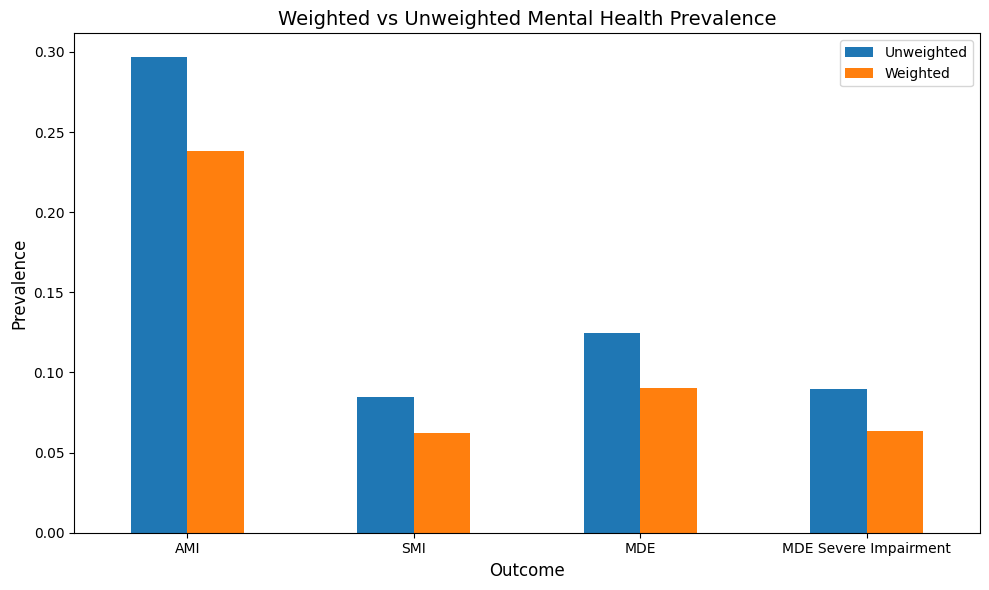

In [80]:
def weighted_mean(df, value_col, weight_col):
    return (df[value_col] * df[weight_col]).sum() / df[weight_col].sum()

weighted_vals = [weighted_mean(analysis_df, col, 'SurveyWeight') for col in ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment']]
unweighted_vals = [analysis_df[col].mean() for col in ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment']]

compare_df = pd.DataFrame({
    'Unweighted': unweighted_vals,
    'Weighted': weighted_vals
}, index=['AMI', 'SMI', 'MDE', 'MDE Severe Impairment'])

fig, ax = plt.subplots() # Create a figure and an axes object
compare_df.plot(kind='bar', ax=ax)
plt.title("Weighted vs Unweighted Mental Health Prevalence")
plt.ylabel("Prevalence")
plt.xlabel("Outcome")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
save_eda_figure(fig, "Weighted vrs Unweighted Mental Health Prevalence.png", result_type="Weighted_Vrs_Unweighted_Figures")
plt.show()

###1.Weighted overall prevalence of Mental Health Outcomes

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_Outcomes.png


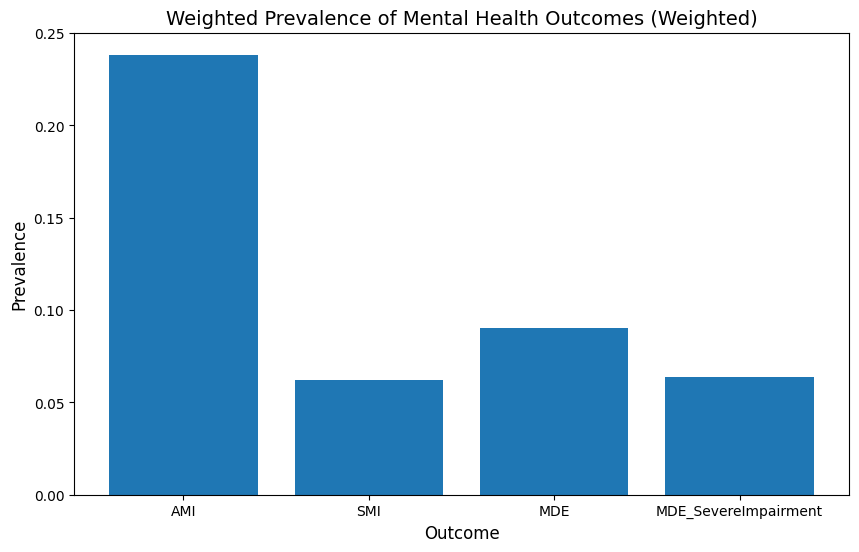

In [81]:
mh_cols = ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment']

weighted_vals = [
    weighted_mean(analysis_df, col, 'SurveyWeight')
    for col in mh_cols
]

# 1. Capture the figure object by assigning it to 'fig'
fig, ax = plt.subplots()

# 2. Use 'ax' for plotting (cleaner than plt.bar)
ax.bar(mh_cols, weighted_vals)
ax.set_title("Weighted Prevalence of Mental Health Outcomes (Weighted)")
ax.set_ylabel("Prevalence")
ax.set_xlabel("Outcome")

save_eda_figure(fig, "Mental_health_Outcomes.png", result_type="Weighted")

plt.show()


###2.Weighted Substance Use Prevalence(2020–2024)

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Substance_Use_Prevalence.png


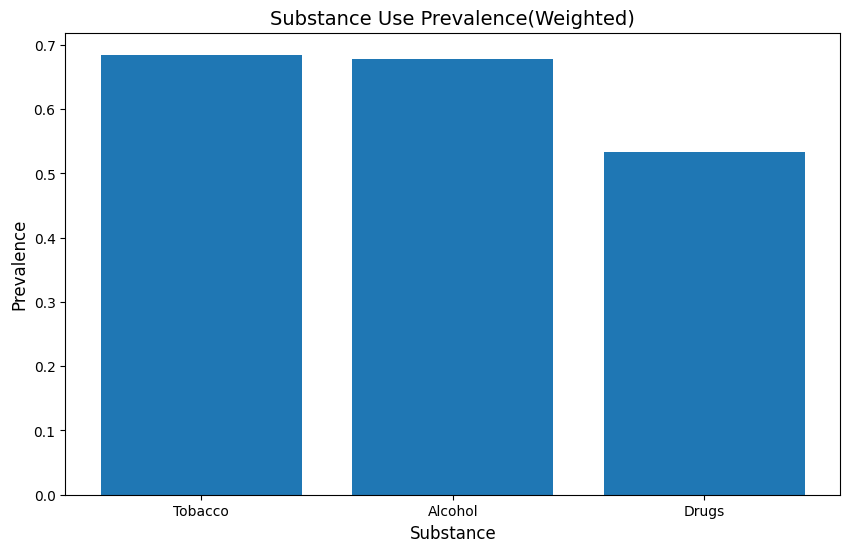

In [82]:
sub_cols = ['Tobacco', 'Alcohol', 'Drugs']

weighted_vals = [
    weighted_mean(analysis_df, col, 'SurveyWeight')
    for col in sub_cols
]

plt.figure()
plt.bar(sub_cols, weighted_vals)
plt.title("Substance Use Prevalence(Weighted)")
plt.ylabel("Prevalence")
plt.xlabel("Substance")
save_eda_figure(fig, "Substance_Use_Prevalence.png", result_type="Weighted")
plt.show()

### 3. Weighted Mental Health Trends Over Time

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_Trends.png


/tmp/ipykernel_2486/1172524727.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_trends = analysis_df.groupby('YEAR').apply(


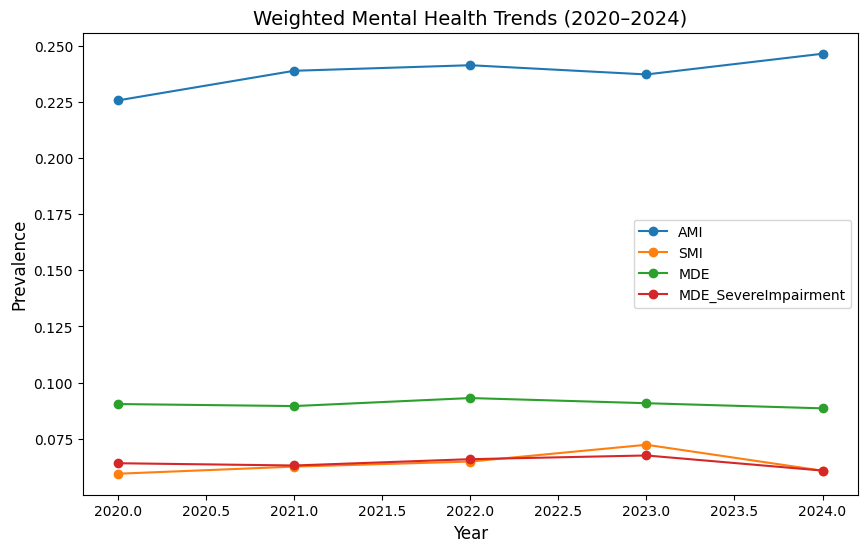

In [83]:
weighted_trends = analysis_df.groupby('YEAR').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })
)

weighted_trends.plot(marker='o')
plt.title("Weighted Mental Health Trends (2020–2024)")
plt.ylabel("Prevalence")
plt.xlabel("Year")
save_eda_figure(fig, "Mental_health_Trends.png", result_type="Weighted")
plt.show()

### 4. Weighted Substance Use Trends

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Substance_Use_Trends.png


/tmp/ipykernel_2486/1572532181.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_sub_trends = analysis_df.groupby('YEAR').apply(


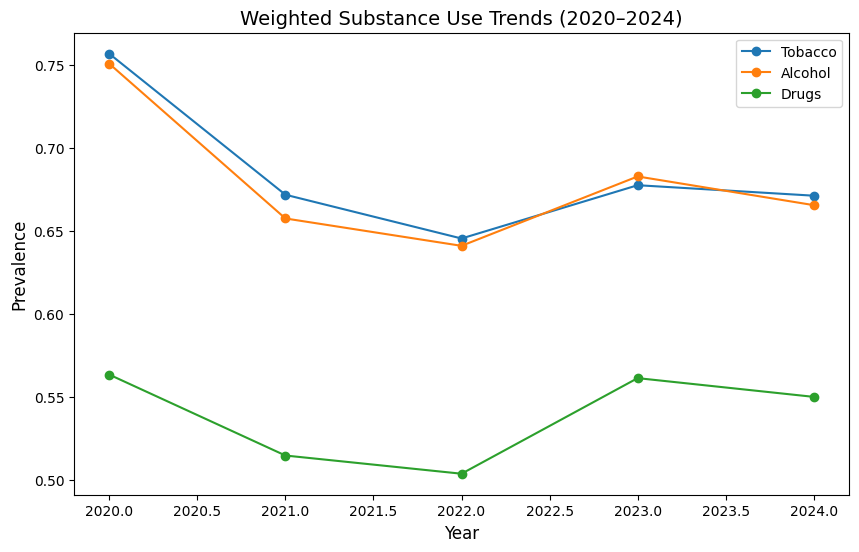

In [84]:
weighted_sub_trends = analysis_df.groupby('YEAR').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['Tobacco','Alcohol','Drugs']
    })
)

weighted_sub_trends.plot(marker='o')
plt.title("Weighted Substance Use Trends (2020–2024)")
plt.ylabel("Prevalence")
plt.xlabel("Year")
save_eda_figure(fig, "Substance_Use_Trends.png", result_type="Weighted")
plt.show()

### 5. Weighted Mental Health by Age Group

/tmp/ipykernel_2486/2696537863.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_weighted = analysis_df.groupby('AgeGroup').apply(
/tmp/ipykernel_2486/2696537863.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_weighted = analysis_df.groupby('AgeGroup').apply(


Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Age_Group.png


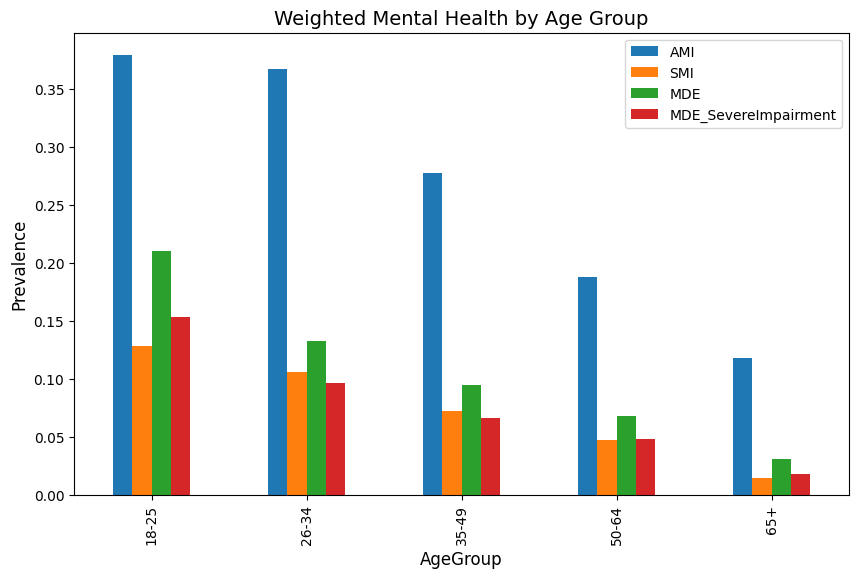

In [85]:
age_weighted = analysis_df.groupby('AgeGroup').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })
)

age_weighted.plot(kind='bar')
plt.title("Weighted Mental Health by Age Group")
plt.ylabel("Prevalence")
save_eda_figure(fig, "Mental_health_by_Age_Group.png", result_type="Weighted")
plt.show()

### 6. Weighted Mental Health by Poverty

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Poverty_Status.png


/tmp/ipykernel_2486/4248462278.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poverty_weighted = analysis_df.groupby('Poverty').apply(
/tmp/ipykernel_2486/4248462278.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  poverty_weighted = analysis_df.groupby('Poverty').apply(


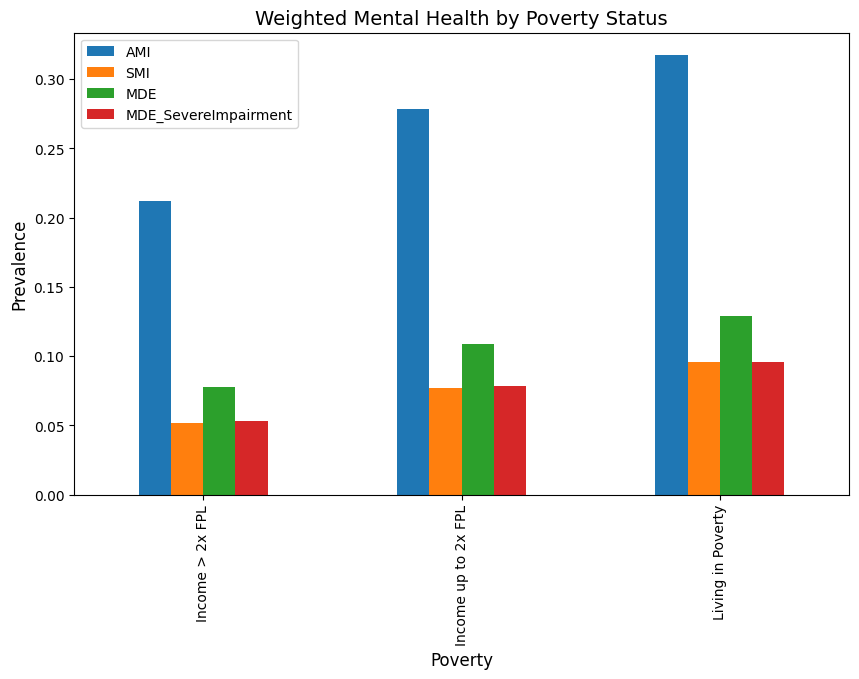

In [86]:
poverty_weighted = analysis_df.groupby('Poverty').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })
)

poverty_weighted.plot(kind='bar')
plt.title("Weighted Mental Health by Poverty Status")
plt.ylabel("Prevalence")
save_eda_figure(fig, "Mental_health_by_Poverty_Status.png", result_type="Weighted")
plt.show()

### 7. Weighted Mental Health by Sex

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Sex.png


/tmp/ipykernel_2486/1407390934.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sex_weighted = analysis_df.groupby('Sex').apply(


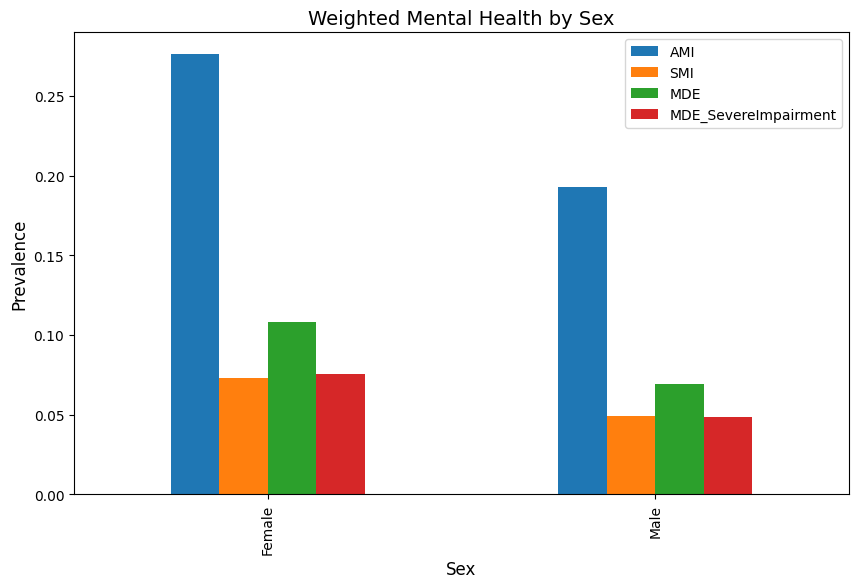

In [87]:
sex_weighted = analysis_df.groupby('Sex').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })
)

sex_weighted.plot(kind='bar')
plt.title("Weighted Mental Health by Sex")
plt.ylabel("Prevalence")
save_eda_figure(fig, "Mental_health_by_Sex.png", result_type="Weighted")
plt.show()

###8.Weighted Mental Health by Family Income

/tmp/ipykernel_2486/2212021182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_weighted = analysis_df.groupby('FamilyIncome').apply(
/tmp/ipykernel_2486/2212021182.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  income_weighted = analysis_df.groupby('FamilyIncome').apply(


Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Family_Income.png


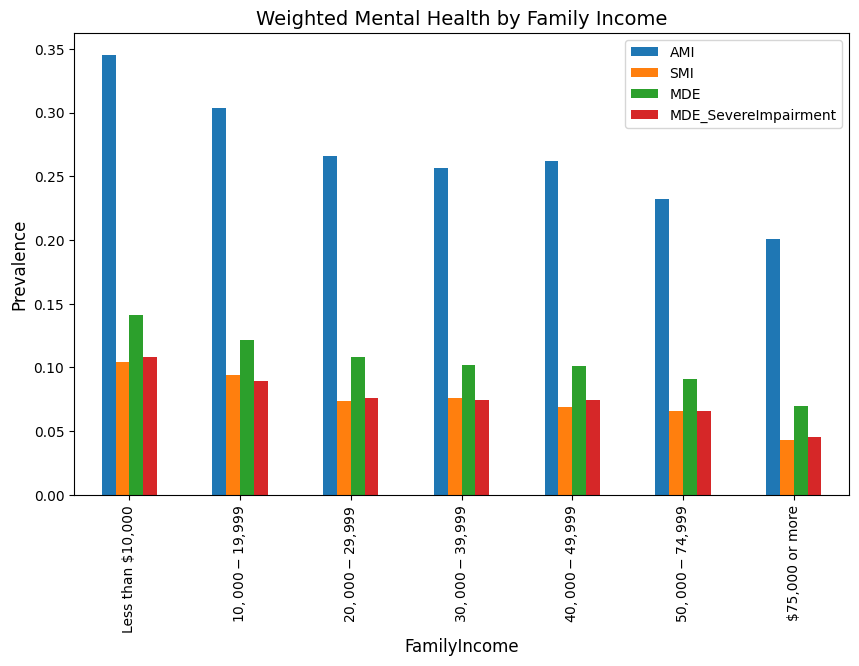

In [88]:
income_weighted = analysis_df.groupby('FamilyIncome').apply(
    lambda df: pd.Series({
        col: weighted_mean(df, col, 'SurveyWeight')
        for col in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })
)

income_weighted.plot(kind='bar')
plt.title("Weighted Mental Health by Family Income")
plt.ylabel("Prevalence")
save_eda_figure(fig, "Mental_health_by_Family_Income.png", result_type="Weighted")
plt.show()

###9.Weighted Associations Between Substance Use and Mental Health

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Substance_Use.png


/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pa

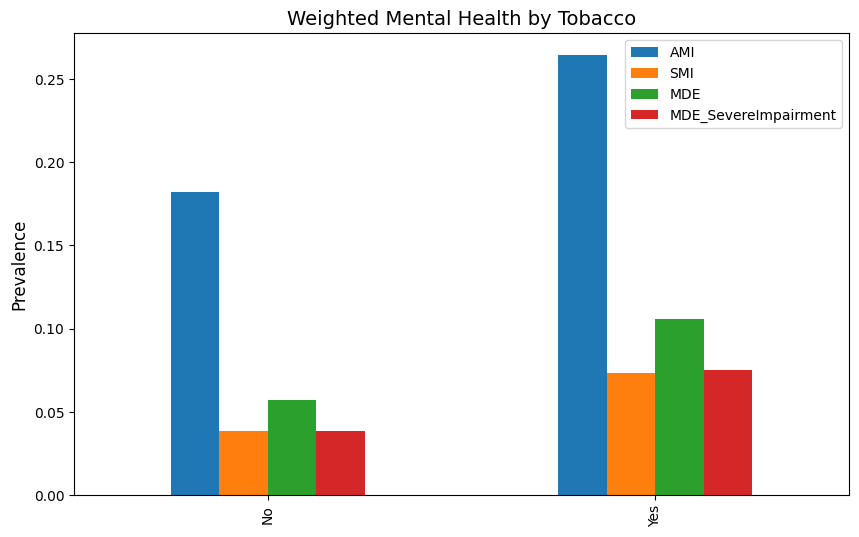

Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Substance_Use.png


/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pa

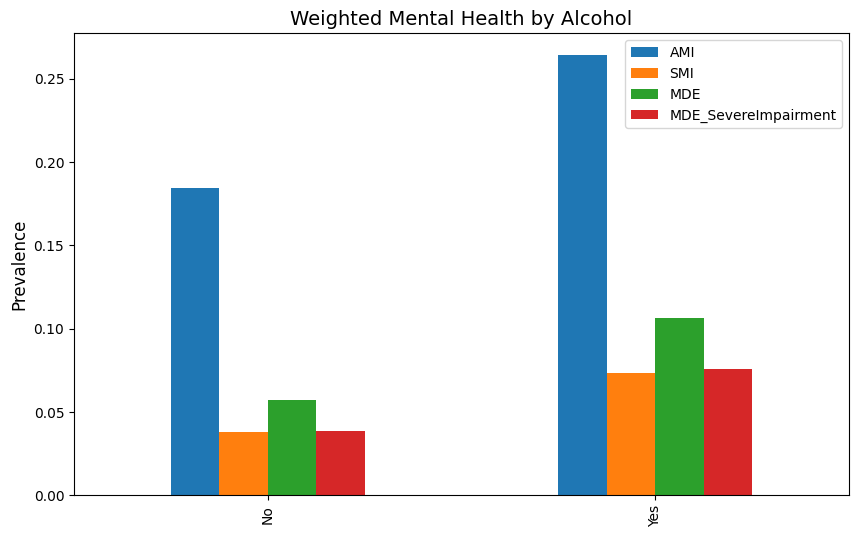

/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(


Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Mental_health_by_Substance_Use.png


/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(
/tmp/ipykernel_2486/1536495314.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pa

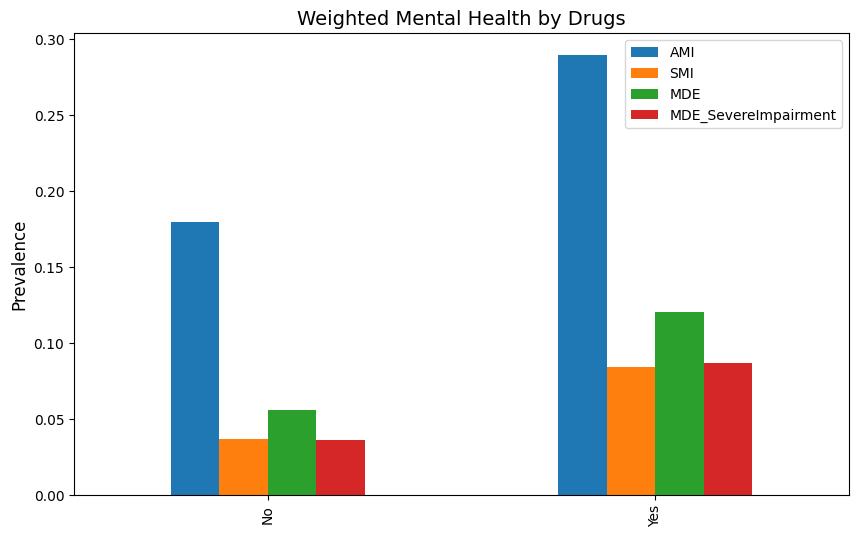

In [89]:
def weighted_group(df, group_col, outcome_col):
    return df.groupby(group_col).apply(
        lambda x: weighted_mean(x, outcome_col, 'SurveyWeight')
    )

for substance in ['Tobacco','Alcohol','Drugs']:
    temp = pd.DataFrame({
        outcome: weighted_group(analysis_df, substance, outcome)
        for outcome in ['AMI','SMI','MDE','MDE_SevereImpairment']
    })

    temp.index = ['No','Yes']

    temp.plot(kind='bar')
    plt.title(f"Weighted Mental Health by {substance}")
    plt.ylabel("Prevalence")
    save_eda_figure(fig, "Mental_health_by_Substance_Use.png", result_type="Weighted")
    plt.show()

###10.Weighted Correlation Heatmap

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def weighted_corr(x, y, w):
    """
    Compute weighted Pearson correlation.
    Works well for binary and continuous variables in EDA.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(w)
    x, y, w = x[mask], y[mask], w[mask]

    if len(x) == 0:
        return np.nan

    wx = np.sum(w * x) / np.sum(w)
    wy = np.sum(w * y) / np.sum(w)

    cov_xy = np.sum(w * (x - wx) * (y - wy)) / np.sum(w)
    var_x = np.sum(w * (x - wx) ** 2) / np.sum(w)
    var_y = np.sum(w * (y - wy) ** 2) / np.sum(w)

    if var_x <= 0 or var_y <= 0:
        return np.nan

    return cov_xy / np.sqrt(var_x * var_y)


def weighted_corr_matrix(df, cols, weight_col):
    """
    Build a weighted correlation matrix.
    """
    mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            mat.loc[c1, c2] = weighted_corr(df[c1], df[c2], df[weight_col])

    return mat

In [91]:
### Choosing Variables for heat maps
corr_vars = [
    'AMI',
    'SMI',
    'MDE',
    'MDE_SevereImpairment',
    'Tobacco',
    'Alcohol',
    'Drugs'
]

###Unweighted Correlation Heat Map of Mental Health and Substance Use Variables

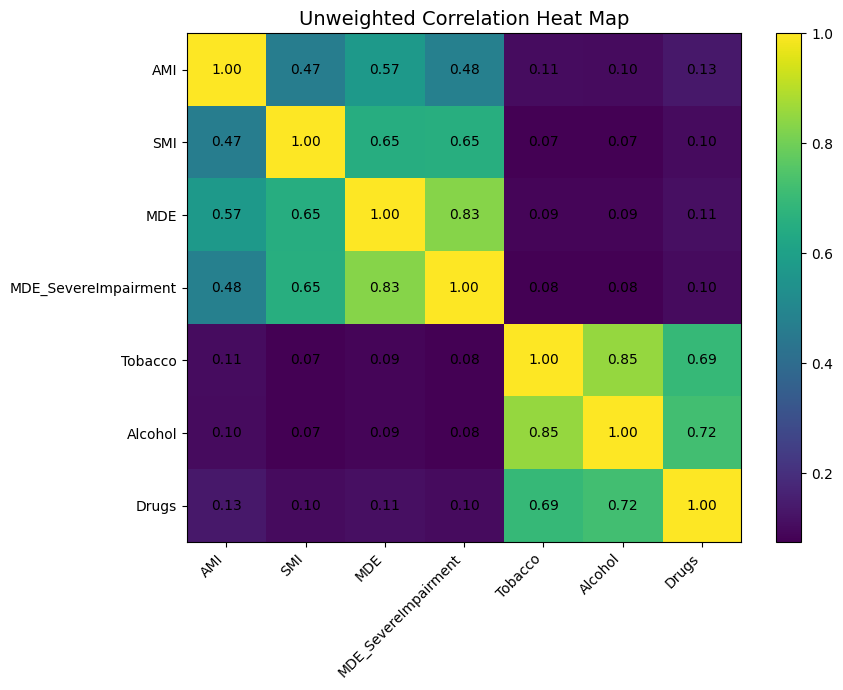

,AMI,SMI,MDE,MDE_SevereImpairment,Tobacco,Alcohol,Drugs
AMI,1.000000,0.467521,0.570044,0.479373,0.106305,0.102759,0.133267
SMI,0.467521,1.000000,0.651646,0.654728,0.074627,0.074783,0.100876
MDE,0.570044,0.651646,1.000000,0.831739,0.088527,0.086990,0.112835
MDE_SevereImpairment,0.479373,0.654728,0.831739,1.000000,0.077715,0.076831,0.100885
Tobacco,0.106305,0.074627,0.088527,0.077715,1.000000,0.853169,0.693869
Alcohol,0.102759,0.074783,0.086990,0.076831,0.853169,1.000000,0.719887
Drugs,0.133267,0.100876,0.112835,0.100885,0.693869,0.719887,1.000000


In [92]:
unweighted_corr = analysis_df[corr_vars].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(unweighted_corr, aspect='auto')
plt.colorbar(im)

plt.xticks(range(len(corr_vars)), corr_vars, rotation=45, ha='right')
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Unweighted Correlation Heat Map")

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        plt.text(j, i, f"{unweighted_corr.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
#plt.savefig(fig_path + "16_unweighted_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

unweighted_corr.to_csv(fig_path + "16_unweighted_correlation_heatmap.csv")
unweighted_corr

### Weighted Correlation Heat Map of Mental Health and Substance Use Variables


Figure saved to: /content/drive/MyDrive/CSV_FILES_PSM691/EDA_Figures/Weighted/Correlation_Heat_Map_of_Mental_health_And_Substance_Use.png


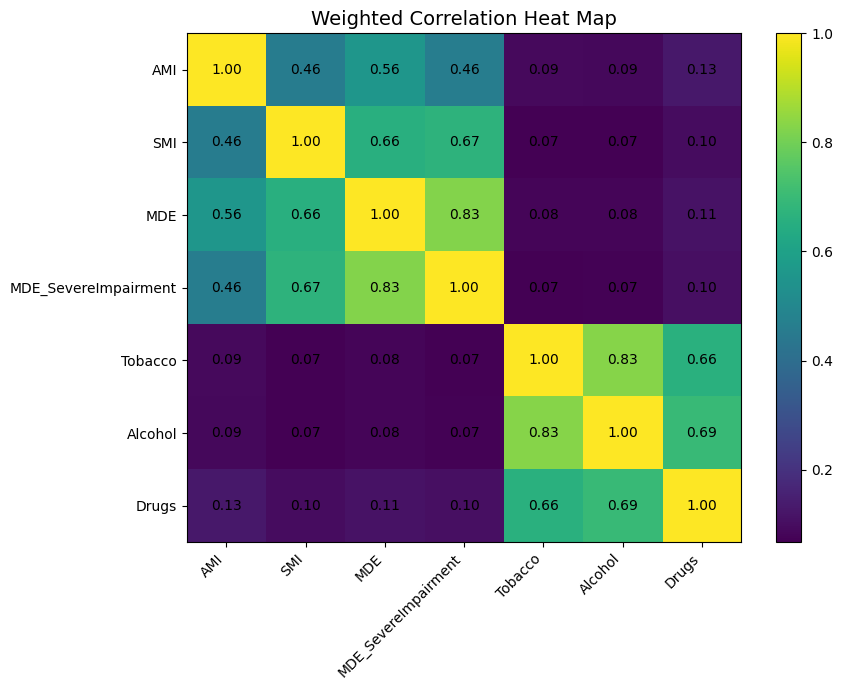

,AMI,SMI,MDE,MDE_SevereImpairment,Tobacco,Alcohol,Drugs
AMI,1.000000,0.460253,0.557110,0.463852,0.089861,0.087701,0.128477
SMI,0.460253,1.000000,0.656013,0.668593,0.067166,0.068720,0.097527
MDE,0.557110,0.656013,1.000000,0.826184,0.079110,0.080266,0.113066
MDE_SevereImpairment,0.463852,0.668593,0.826184,1.000000,0.069816,0.071164,0.103748
Tobacco,0.089861,0.067166,0.079110,0.069816,1.000000,0.831729,0.658410
Alcohol,0.087701,0.068720,0.080266,0.071164,0.831729,1.000000,0.694435
Drugs,0.128477,0.097527,0.113066,0.103748,0.658410,0.694435,1.000000


In [93]:
weighted_corr_mat = weighted_corr_matrix(analysis_df, corr_vars, 'SurveyWeight')

plt.figure(figsize=(9, 7))
im = plt.imshow(weighted_corr_mat, aspect='auto')
plt.colorbar(im)

plt.xticks(range(len(corr_vars)), corr_vars, rotation=45, ha='right')
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Weighted Correlation Heat Map")

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        plt.text(j, i, f"{weighted_corr_mat.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
save_eda_figure(fig, "Correlation_Heat_Map_of_Mental_health_And_Substance_Use.png", result_type="Weighted")
plt.show()

weighted_corr_mat.to_csv(fig_path + "17_weighted_correlation_heatmap.csv")
weighted_corr_mat

###**Logistic Regression Modeling Setup**




In [94]:
import os
import numpy as np
import pandas as pd
!pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

results_path = mainPath + "Regression_Results/"
os.makedirs(results_path, exist_ok=True)

print("Regression outputs will be saved to:", results_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.4 MB/s eta 0:00:00
Regression outputs will be saved to: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/


### Prepare Variables for Regression

In [95]:
model_df = analysis_df.copy()

# Convert binary variables from pandas nullable Int64 / float to plain numeric
binary_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs'
]

for col in binary_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce').astype(float)

# Convert survey weight to plain float
model_df['SurveyWeight'] = pd.to_numeric(model_df['SurveyWeight'], errors='coerce').astype(float)

# Convert YEAR to standard int first, then to category to avoid patsy issues with Int64Dtype
model_df['YEAR'] = model_df['YEAR'].astype(int).astype('category')
model_df['Sex'] = model_df['Sex'].astype('category')
model_df['Race'] = model_df['Race'].astype('category')
model_df['AgeGroup'] = model_df['AgeGroup'].astype('category')
model_df['CountyType'] = model_df['CountyType'].astype('category')
model_df['Poverty'] = model_df['Poverty'].astype('category')
model_df['FamilyIncome'] = model_df['FamilyIncome'].astype('category')

# Normalize weights so they sum to the analytic sample size
model_df['SurveyWeight_norm'] = (
    model_df['SurveyWeight'] * (len(model_df) / model_df['SurveyWeight'].sum())
).astype(float)

print(model_df.shape)
print(model_df[['SurveyWeight', 'SurveyWeight_norm']].describe())
model_df.head()

(131426, 16)
        SurveyWeight  SurveyWeight_norm
count  131426.000000      131426.000000
mean     6287.997899           1.000000
std     10307.918942           1.639301
min         0.953663           0.000152
25%       809.691500           0.128768
50%      2591.391107           0.412117
75%      7317.741378           1.163763
max    222288.176600          35.351185


,YEAR,SurveyWeight,CountyType,AgeGroup,Sex,Race,Poverty,FamilyIncome,AMI,SMI,MDE,MDE_SevereImpairment,Tobacco,Alcohol,Drugs,SurveyWeight_norm
0,2020,16186.579070,Nonmetro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$75,000 or more",0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.574202
1,2020,16809.072850,Small Metro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$50,000-$74,999",1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.673200
2,2020,1379.866862,Large Metro,26-34,Female,Non-Hispanic More Than One Race,Income > 2x FPL,"$30,000-$39,999",1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.219445
3,2020,422.776340,Large Metro,35-49,Male,Non-Hispanic White,Income > 2x FPL,"$75,000 or more",0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.067235
5,2020,2529.748991,Small Metro,18-25,Female,Hispanic,Income > 2x FPL,"$40,000-$49,999",0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.402314


#**Logistic Regression Results**

### Normalize Survey Weights for Regression

### Weighted Logistic Regression Models

In [96]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

formula_ami = """
AMI ~ Tobacco + Alcohol + Drugs
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty) + C(YEAR)
"""

formula_smi = """
SMI ~ Tobacco + Alcohol + Drugs
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty) + C(YEAR)
"""

formula_mde = """
MDE ~ Tobacco + Alcohol + Drugs
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty) + C(YEAR)
"""

formula_mde_severe = """
MDE_SevereImpairment ~ Tobacco + Alcohol + Drugs
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty) + C(YEAR)
"""

# Weighted models
w_ami = smf.glm(
    formula=formula_ami,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_smi = smf.glm(
    formula=formula_smi,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_mde = smf.glm(
    formula=formula_mde,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_mde_severe = smf.glm(
    formula=formula_mde_severe,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

# Unweighted models - ADDED
unw_ami = smf.glm(
    formula=formula_ami,
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

unw_smi = smf.glm(
    formula=formula_smi,
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

unw_mde = smf.glm(
    formula=formula_mde,
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

unw_mde_severe = smf.glm(
    formula=formula_mde_severe,
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type='HC1')


print(w_ami.summary())
print(w_smi.summary())
print(w_mde.summary())
print(w_mde_severe.summary())

# Print unweighted summaries too (optional, but good for completeness)
print(unw_ami.summary())
print(unw_smi.summary())
print(unw_mde.summary())
print(unw_mde_severe.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    AMI   No. Observations:               131426
Model:                            GLM   Df Residuals:                131403.00
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66468.
Date:                Thu, 14 May 2026   Deviance:                   1.3294e+05
Time:                        03:45:26   Pearson chi2:                 1.32e+05
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08309
Covariance Type:                  HC1                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

### Save Odds Ratios, Confidence Intervals, and P-values

In [97]:
def extract_or_table(model, model_name):
    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    out = pd.DataFrame({
        'term': params.index,
        'coef': params.values,
        'OR': np.exp(params.values),
        'CI_lower': np.exp(conf[0].values),
        'CI_upper': np.exp(conf[1].values),
        'p_value': pvals.values
    })

    out['model'] = model_name
    return out

or_w_ami = extract_or_table(w_ami, "Weighted AMI")
or_w_smi = extract_or_table(w_smi, "Weighted SMI")
or_w_mde = extract_or_table(w_mde, "Weighted MDE")
or_w_mde_severe = extract_or_table(w_mde_severe, "Weighted MDE Severe")

# Extract ORs for unweighted models - ADDED
or_unw_ami = extract_or_table(unw_ami, "Unweighted AMI")
or_unw_smi = extract_or_table(unw_smi, "Unweighted SMI")
or_unw_mde = extract_or_table(unw_mde, "Unweighted MDE")
or_unw_mde_severe = extract_or_table(unw_mde_severe, "Unweighted MDE Severe")

all_or_results = pd.concat([
    or_unw_ami, or_unw_smi, or_unw_mde, or_unw_mde_severe,
    or_w_ami, or_w_smi, or_w_mde, or_w_mde_severe
], ignore_index=True)

all_or_results.to_csv(results_path + "01_all_model_odds_ratios.csv", index=False)
all_or_results.head(20)

,term,coef,OR,CI_lower,CI_upper,p_value,model
0,Intercept,-1.233920,0.291149,0.274952,0.308300,0.000000e+00,Unweighted AMI
1,C(Sex)[T.Male],-0.446415,0.639918,0.623563,0.656702,2.390077e-250,Unweighted AMI
2,C(Race)[T.Non-Hispanic Asian],-0.145317,0.864748,0.807259,0.926332,3.471553e-05,Unweighted AMI
3,C(Race)[T.Non-Hispanic Black],-0.190627,0.826441,0.784326,0.870817,9.106300e-13,Unweighted AMI
4,C(Race)[T.Non-Hispanic More Than One Race],0.537820,1.712270,1.600637,1.831690,4.188066e-55,Unweighted AMI
5,C(Race)[T.Non-Hispanic Native American/AK Native],0.156895,1.169873,1.035881,1.321196,1.147228e-02,Unweighted AMI
6,C(Race)[T.Non-Hispanic Native Hawaiian/Pacific...,-0.121861,0.885272,0.707104,1.108331,2.878433e-01,Unweighted AMI
7,C(Race)[T.Non-Hispanic White],0.361467,1.435434,1.382277,1.490636,1.221242e-78,Unweighted AMI
8,C(AgeGroup)[T.26-34],0.037456,1.038166,1.003111,1.074447,3.258278e-02,Unweighted AMI
9,C(AgeGroup)[T.35-49],-0.309405,0.733883,0.710467,0.758071,4.864774e-78,Unweighted AMI


### Weighted vs Unweighted Comparison Table

In [98]:
key_terms = ['Tobacco', 'Alcohol', 'Drugs']

compare_models = all_or_results[all_or_results['term'].isin(key_terms)].copy()
compare_models.to_csv(results_path + "02_weighted_unweighted_key_terms_comparison.csv", index=False)
compare_models

,term,coef,OR,CI_lower,CI_upper,p_value,model
20,Tobacco,0.224494,1.251689,1.181347,1.326220,2.797824e-14,Unweighted AMI
21,Alcohol,0.029383,1.029819,0.970019,1.093305,3.357123e-01,Unweighted AMI
22,Drugs,0.318209,1.374663,1.321868,1.429566,4.223443e-57,Unweighted AMI
43,Tobacco,0.162680,1.176660,1.063661,1.301663,1.588340e-03,Unweighted SMI
44,Alcohol,0.085796,1.089584,0.982309,1.208573,1.047130e-01,Unweighted SMI
45,Drugs,0.509327,1.664170,1.551301,1.785251,7.537736e-46,Unweighted SMI
66,Tobacco,0.245141,1.277801,1.175677,1.388796,8.013975e-09,Unweighted MDE
67,Alcohol,0.081732,1.085165,0.996246,1.182021,6.096566e-02,Unweighted MDE
68,Drugs,0.412923,1.511228,1.427444,1.599930,1.069291e-45,Unweighted MDE
89,Tobacco,0.231924,1.261024,1.144303,1.389651,2.868714e-06,Unweighted MDE Severe


#**Interaction Models: Substance Use by Year**

In [99]:
formula_ami_interact = """
AMI ~ Tobacco*C(YEAR) + Alcohol*C(YEAR) + Drugs*C(YEAR)
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty)
"""

formula_smi_interact = """
SMI ~ Tobacco*C(YEAR) + Alcohol*C(YEAR) + Drugs*C(YEAR)
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty)
"""

formula_mde_interact = """
MDE ~ Tobacco*C(YEAR) + Alcohol*C(YEAR) + Drugs*C(YEAR)
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty)
"""
formula_mde_severe_interact = """
MDE_SevereImpairment ~ Tobacco*C(YEAR) + Alcohol*C(YEAR) + Drugs*C(YEAR)
+ C(Sex) + C(Race) + C(AgeGroup) + C(CountyType) + C(Poverty)
"""


### Weighted interaction models

In [100]:
w_ami_interact = smf.glm(
    formula=formula_ami_interact,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_smi_interact = smf.glm(
    formula=formula_smi_interact,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_mde_interact = smf.glm(
    formula=formula_mde_interact,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

w_mde_severe_interact = smf.glm(
    formula=formula_mde_severe_interact,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')


print(w_ami_interact.summary())
print(w_smi_interact.summary())
print(w_mde_interact.summary())
print(w_mde_severe_interact.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    AMI   No. Observations:               131426
Model:                            GLM   Df Residuals:                131391.00
Model Family:                Binomial   Df Model:                           34
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66453.
Date:                Thu, 14 May 2026   Deviance:                   1.3291e+05
Time:                        03:46:01   Pearson chi2:                 1.32e+05
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08330
Covariance Type:                  HC1                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

### Save Interaction Tables

In [101]:
or_w_ami_interact = extract_or_table(w_ami_interact, "Weighted AMI Interaction")
or_w_smi_interact = extract_or_table(w_smi_interact, "Weighted SMI Interaction")
or_w_mde_interact = extract_or_table(w_mde_interact, "Weighted MDE Interaction")
or_w_mde_severe_interact = extract_or_table(w_mde_interact, "Weighted MDE_Severe Interaction")

interaction_results = pd.concat([
    or_w_ami_interact,
    or_w_smi_interact,
    or_w_mde_interact,
    or_w_mde_severe_interact
], ignore_index=True)

interaction_results.to_csv(results_path + "03_interaction_model_results.csv", index=False)
interaction_results.head(30)

,term,coef,OR,CI_lower,CI_upper,p_value,model
0,Intercept,-1.232027,0.291701,0.268461,0.316952,5.433763e-186,Weighted AMI Interaction
1,C(YEAR)[T.2021],0.085617,1.089389,1.000527,1.186143,4.859916e-02,Weighted AMI Interaction
2,C(YEAR)[T.2022],0.088706,1.092760,1.005276,1.187856,3.719922e-02,Weighted AMI Interaction
3,C(YEAR)[T.2023],0.194327,1.214494,1.002411,1.471448,4.719422e-02,Weighted AMI Interaction
4,C(YEAR)[T.2024],0.190576,1.209946,1.113022,1.315310,7.695462e-06,Weighted AMI Interaction
5,C(Sex)[T.Male],-0.449221,0.638125,0.620964,0.655761,7.680685e-229,Weighted AMI Interaction
6,C(Race)[T.Non-Hispanic Asian],-0.212503,0.808558,0.751296,0.870184,1.425337e-08,Weighted AMI Interaction
7,C(Race)[T.Non-Hispanic Black],-0.027085,0.973278,0.921860,1.027564,3.280395e-01,Weighted AMI Interaction
8,C(Race)[T.Non-Hispanic More Than One Race],0.710941,2.035905,1.852445,2.237535,2.838697e-49,Weighted AMI Interaction
9,C(Race)[T.Non-Hispanic Native American/AK Native],0.202676,1.224676,1.011596,1.482638,3.769284e-02,Weighted AMI Interaction


### Likelihood Ratio Test

In [102]:
from scipy.stats import chi2

def lr_test(main_model, interaction_model, outcome_name):
    lr_stat = 2 * (interaction_model.llf - main_model.llf)
    df_diff = interaction_model.df_model - main_model.df_model
    p_value = chi2.sf(lr_stat, df_diff)
    print(f"{outcome_name}: LR statistic = {lr_stat:.3f}, df = {int(df_diff)}, p = {p_value:.4f}")
    return lr_stat, df_diff, p_value

lr_results = {}
for outcome, main, interact in [
    ('AMI', w_ami, w_ami_interact),
    ('SMI', w_smi, w_smi_interact),
    ('MDE', w_mde, w_mde_interact),
    ('MDE_Severe', w_mde_severe, w_mde_severe_interact)
]:
    lr_results[outcome] = lr_test(main, interact, outcome)

# Save to CSV
lr_df = pd.DataFrame([
    {'Outcome': k, 'LR_Stat': v[0], 'df': v[1], 'p_value': v[2]}
    for k, v in lr_results.items()
])
lr_df.to_csv(results_path + "09_likelihood_ratio_tests.csv", index=False)
print(lr_df)


AMI: LR statistic = 29.155, df = 12, p = 0.0037
SMI: LR statistic = 49.985, df = 12, p = 0.0000
MDE: LR statistic = 49.867, df = 12, p = 0.0000
MDE_Severe: LR statistic = 26.001, df = 12, p = 0.0107
      Outcome    LR_Stat  df   p_value
0         AMI  29.154811  12  0.003737
1         SMI  49.985097  12  0.000001
2         MDE  49.867332  12  0.000001
3  MDE_Severe  26.000970  12  0.010730


###Model summary table

In [103]:
main_terms_keep = [
    'Tobacco', 'Alcohol', 'Drugs'
]

weighted_main_summary = pd.concat([
    or_w_ami.assign(outcome='AMI'),
    or_w_smi.assign(outcome='SMI'),
    or_w_mde.assign(outcome='MDE'),
    or_w_mde_severe.assign(outcome='MDE Severe Impairment')
], ignore_index=True)

weighted_main_summary = weighted_main_summary[
    weighted_main_summary['term'].isin(main_terms_keep)
].copy()

weighted_main_summary = weighted_main_summary[
    ['outcome', 'term', 'OR', 'CI_lower', 'CI_upper', 'p_value']
]

weighted_main_summary.to_csv(results_path + "Weighted_main_summary_table.csv", index=False)
weighted_main_summary

,outcome,term,OR,CI_lower,CI_upper,p_value
20,AMI,Tobacco,1.155998,1.092292,1.223419,5.378531e-07
21,AMI,Alcohol,1.000527,0.942693,1.061908,9.861704e-01
22,AMI,Drugs,1.426224,1.369602,1.485187,3.943216e-66
43,SMI,Tobacco,1.116147,1.002106,1.243166,4.569175e-02
44,SMI,Alcohol,1.106620,0.986954,1.240796,8.273061e-02
45,SMI,Drugs,1.672533,1.545159,1.810407,4.219954e-37
66,MDE,Tobacco,1.146019,1.048362,1.252772,2.706153e-03
67,MDE,Alcohol,1.078616,0.982227,1.184465,1.130802e-01
68,MDE,Drugs,1.665433,1.561931,1.775793,9.714903e-55
89,MDE Severe Impairment,Tobacco,1.118813,1.005093,1.245400,4.008734e-02


## Forest Plot of Weighted Adjusted Odds Ratios

In [106]:
model_df = analysis_df.copy()

# Normalize weights so they sum to the analytic sample size
model_df['SurveyWeight_norm'] = (
    model_df['SurveyWeight'] * (len(model_df) / model_df['SurveyWeight'].sum())
)

print(model_df[['SurveyWeight', 'SurveyWeight_norm']].describe())


        SurveyWeight  SurveyWeight_norm
count  131426.000000      131426.000000
mean     6287.997899           1.000000
std     10307.918942           1.639301
min         0.953663           0.000152
25%       809.691500           0.128768
50%      2591.391107           0.412117
75%      7317.741378           1.163763
max    222288.176600          35.351185


In [108]:
model_df = analysis_df.copy()

# Convert binary variables from pandas nullable Int64 / float to plain numeric
binary_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs'
]

for col in binary_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce').astype(float)

# Convert survey weight to plain float
model_df['SurveyWeight'] = pd.to_numeric(model_df['SurveyWeight'], errors='coerce').astype(float)

# YEAR should be plain integer first, then category
model_df['YEAR'] = pd.to_numeric(model_df['YEAR'], errors='coerce').astype(int)
model_df['YEAR'] = model_df['YEAR'].astype('category')

# Categorical controls
cat_cols = ['Sex', 'Race', 'AgeGroup', 'CountyType', 'Poverty', 'FamilyIncome']
for col in cat_cols:
    model_df[col] = model_df[col].astype('category')

# Normalize weights
model_df['SurveyWeight_norm'] = (
    model_df['SurveyWeight'] * (len(model_df) / model_df['SurveyWeight'].sum())
).astype(float)

# Check dtypes
print(model_df.dtypes)

YEAR                    category
SurveyWeight             float64
CountyType              category
AgeGroup                category
Sex                     category
Race                    category
Poverty                 category
FamilyIncome            category
AMI                      float64
SMI                      float64
MDE                      float64
MDE_SevereImpairment     float64
Tobacco                  float64
Alcohol                  float64
Drugs                    float64
SurveyWeight_norm        float64
dtype: object


In [109]:
def extract_or_table(model, model_name):
    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    out = pd.DataFrame({
        'term': params.index,
        'coef': params.values,
        'OR': np.exp(params.values),
        'CI_lower': np.exp(conf[0].values),
        'CI_upper': np.exp(conf[1].values),
        'p_value': pvals.values
    })

    out['model'] = model_name
    return out

or_w_ami = extract_or_table(w_ami, "Weighted AMI")
or_w_smi = extract_or_table(w_smi, "Weighted SMI")
or_w_mde = extract_or_table(w_mde, "Weighted MDE")
or_w_mde_severe = extract_or_table(w_mde_severe, "Weighted MDE Severe")


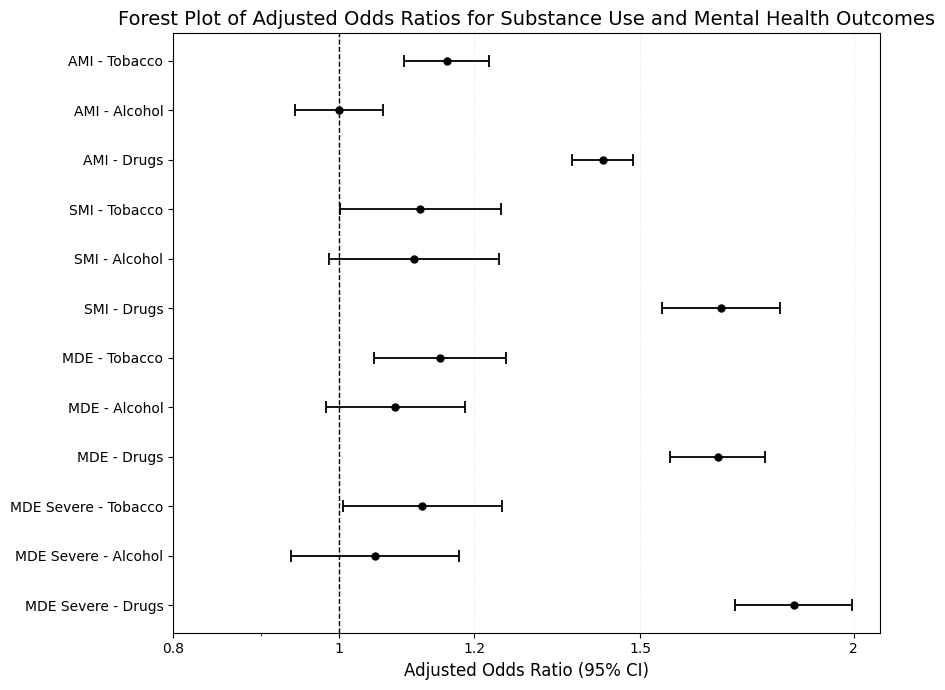

In [110]:
import matplotlib.pyplot as plt
import numpy as np

forest_df = weighted_main_summary.copy()
forest_df['label'] = forest_df['outcome'] + " - " + forest_df['term']

forest_df['label'] = forest_df['label'].replace({
    'MDE Severe Impairment - Tobacco': 'MDE Severe - Tobacco',
    'MDE Severe Impairment - Alcohol': 'MDE Severe - Alcohol',
    'MDE Severe Impairment - Drugs': 'MDE Severe - Drugs'
})

order = [
    'AMI - Tobacco', 'AMI - Alcohol', 'AMI - Drugs',
    'SMI - Tobacco', 'SMI - Alcohol', 'SMI - Drugs',
    'MDE - Tobacco', 'MDE - Alcohol', 'MDE - Drugs',
    'MDE Severe - Tobacco', 'MDE Severe - Alcohol', 'MDE Severe - Drugs'
]

forest_df = forest_df.set_index('label').loc[order].reset_index()

y_pos = np.arange(len(forest_df))

# Asymmetric x-errors for the CI
xerr = np.vstack([
    forest_df['OR'] - forest_df['CI_lower'],
    forest_df['CI_upper'] - forest_df['OR']
])

plt.figure(figsize=(9, 7))

plt.errorbar(
    forest_df['OR'],
    y_pos,
    xerr=xerr,
    fmt='o',
    color='black',
    ecolor='black',
    elinewidth=1.3,
    capsize=4,      # <- THIS creates the end caps
    capthick=1.3,
    markersize=5
)

plt.axvline(x=1, linestyle='--', color='black', linewidth=1)

plt.yticks(y_pos, forest_df['label'])
plt.xlabel("Adjusted Odds Ratio (95% CI)")
plt.title("Forest Plot of Adjusted Odds Ratios for Substance Use and Mental Health Outcomes")

plt.xscale('log')
plt.xticks([0.8, 1.0, 1.2, 1.5, 2.0], ['0.8', '1', '1.2', '1.5', '2'])

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig(results_path + "final_forest_plot_with_caps.png", dpi=300, bbox_inches='tight')
plt.show()

In [111]:
forest_df['CI_width'] = forest_df['CI_upper'] - forest_df['CI_lower']
forest_df[['label', 'OR', 'CI_lower', 'CI_upper', 'CI_width', 'p_value']]

,label,OR,CI_lower,CI_upper,CI_width,p_value
0,AMI - Tobacco,1.155998,1.092292,1.223419,0.131127,5.378531e-07
1,AMI - Alcohol,1.000527,0.942693,1.061908,0.119215,9.861704e-01
2,AMI - Drugs,1.426224,1.369602,1.485187,0.115585,3.943216e-66
3,SMI - Tobacco,1.116147,1.002106,1.243166,0.241059,4.569175e-02
4,SMI - Alcohol,1.106620,0.986954,1.240796,0.253843,8.273061e-02
5,SMI - Drugs,1.672533,1.545159,1.810407,0.265248,4.219954e-37
6,MDE - Tobacco,1.146019,1.048362,1.252772,0.204410,2.706153e-03
7,MDE - Alcohol,1.078616,0.982227,1.184465,0.202238,1.130802e-01
8,MDE - Drugs,1.665433,1.561931,1.775793,0.213863,9.714903e-55
9,MDE Severe - Tobacco,1.118813,1.005093,1.245400,0.240308,4.008734e-02


table1_vars = ['Sex', 'Race', 'AgeGroup', 'CountyType', 'Poverty', 'FamilyIncome']

table1_list = []

for var in table1_vars:
    tab = pd.crosstab(model_df[var], model_df['AMI'], normalize='columns') * 100
    tab = tab.round(1)
    tab['Variable'] = var
    tab['Category'] = tab.index
    table1_list.append(tab.reset_index(drop=True))

table1 = pd.concat(table1_list, ignore_index=True)
table1.to_csv(results_path + "08_table1_sample_characteristics_by_AMI.csv", index=False)
table1.head(20)

In [112]:
table1_vars = ['Sex', 'Race', 'AgeGroup', 'CountyType', 'Poverty', 'FamilyIncome']

table1_list = []

for var in table1_vars:
    tab = pd.crosstab(model_df[var], model_df['AMI'], normalize='columns') * 100
    tab = tab.round(1)
    tab['Variable'] = var
    tab['Category'] = tab.index
    table1_list.append(tab.reset_index(drop=True))

table1 = pd.concat(table1_list, ignore_index=True)
table1.to_csv(results_path + "08_table1_sample_characteristics_by_AMI.csv", index=False)
table1.head(20)

AMI,0.0,1.0,Variable,Category
0,56.2,67.7,Sex,Female
1,43.8,32.3,Sex,Male
2,15.2,14.2,Race,Hispanic
3,5.5,3.7,Race,Non-Hispanic Asian
4,11.6,8.4,Race,Non-Hispanic Black
5,3.2,5.1,Race,Non-Hispanic More Than One Race
6,1.1,1.2,Race,Non-Hispanic Native American/AK Native
7,0.4,0.3,Race,Non-Hispanic Native Hawaiian/Pacific Islander
8,63.0,67.2,Race,Non-Hispanic White
9,24.2,34.4,AgeGroup,18-25


### Model Fit Summary

In [113]:
fit_summary = pd.DataFrame({
    'Model': ['Unweighted AMI', 'Unweighted SMI', 'Unweighted MDE', 'Unweighted MDE Severe',
              'Weighted AMI', 'Weighted SMI', 'Weighted MDE', 'Weighted MDE Severe'],
    'AIC': [unw_ami.aic, unw_smi.aic, unw_mde.aic, unw_mde_severe.aic,
            w_ami.aic, w_smi.aic, w_mde.aic, w_mde_severe.aic]
})

fit_summary.to_csv(results_path + "10_model_fit_summary.csv", index=False)
fit_summary

,Model,AIC
0,Unweighted AMI,148775.444537
1,Unweighted SMI,70607.902905
2,Unweighted MDE,91187.598786
3,Unweighted MDE Severe,73141.359507
4,Weighted AMI,132981.190910
5,Weighted SMI,55827.451938
6,Weighted MDE,72681.055918
7,Weighted MDE Severe,56532.788787


### SENSITIVITY ANALYSIS

In [114]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

# Load your cleaned analysis dataframe (ensure the path is correct)
file_path = mainPath + 'nsduh_2020_2024_final_standardized.csv'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please ensure the file was saved correctly in the previous steps.")
    raise FileNotFoundError(f"'{file_path}' not found.")

df = pd.read_csv(file_path)

# Prepare model_df similar to the previous regression setup
model_df_sensitivity = df.copy()

# Convert binary variables from pandas nullable Int64 / float to plain numeric
binary_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs'
]

for col in binary_cols:
    model_df_sensitivity[col] = pd.to_numeric(model_df_sensitivity[col], errors='coerce').astype(float)

# Convert survey weight to plain float
model_df_sensitivity['SurveyWeight'] = pd.to_numeric(model_df_sensitivity['SurveyWeight'], errors='coerce').astype(float)

# YEAR should be plain integer first, then category
model_df_sensitivity['YEAR'] = pd.to_numeric(model_df_sensitivity['YEAR'], errors='coerce').astype(int)
model_df_sensitivity['YEAR'] = model_df_sensitivity['YEAR'].astype('category')

# Categorical controls
cat_cols = ['Sex', 'Race', 'AgeGroup', 'CountyType', 'Poverty', 'FamilyIncome']
for col in cat_cols:
    model_df_sensitivity[col] = model_df_sensitivity[col].astype('category')

# Normalize weights
model_df_sensitivity['SurveyWeight_norm'] = (
    model_df_sensitivity['SurveyWeight'] * (len(model_df_sensitivity) / model_df_sensitivity['SurveyWeight'].sum())
).astype(float)


# Outcome mapping
outcomes_map = {
    'AMI': 'AMI',
    'SMI': 'SMI',
    'MDE': 'MDE',
    'MDE_SevereImpairment': 'MDE_SevereImpairment'
}

sensitivity_results = []

for condition in ['exclude_no_response', 'include_no_response']:

    if condition == 'exclude_no_response':
        # Keep only valid 0/1 rows for all three substance vars
        analysis_df_filtered = model_df_sensitivity[
            model_df_sensitivity['Tobacco'].isin([0, 1]) &
            model_df_sensitivity['Alcohol'].isin([0, 1]) &
            model_df_sensitivity['Drugs'].isin([0, 1])
        ].copy()

    else:
        # Keep all rows; recode missing as 0 (no use, no response)
        analysis_df_filtered = model_df_sensitivity.copy()

        for col in ['Tobacco', 'Alcohol', 'Drugs']:
            # Here, NaN is treated as 'No' (0) for the purpose of 'ANY_SUBSTANCE_USE'
            # For individual substance use, NaN represents no response and won't be '1'
            analysis_df_filtered[col] = analysis_df_filtered[col].fillna(2) # Treat NaN as 0 (no use)

    # Build ANY_SUBSTANCE_USE based on the current filtered/recoded data
    analysis_df_filtered['ANY_SUBSTANCE_USE'] = (
        (analysis_df_filtered['Tobacco'] == 1) |
        (analysis_df_filtered['Alcohol'] == 1) |
        (analysis_df_filtered['Drugs'] == 1)
    ).astype(int)


    # Define independent variables (X)
    numeric_cols = ['ANY_SUBSTANCE_USE']
    categorical_cols = ['YEAR', 'AgeGroup', 'Sex', 'Race', 'Poverty']

    # Dummify categorical columns
    X_categorical = pd.get_dummies(analysis_df_filtered[categorical_cols], drop_first=True, dtype=int)

    # Combine numeric and dummified categorical columns
    X_s = pd.concat([analysis_df_filtered[numeric_cols], X_categorical], axis=1)
    X_s = sm.add_constant(X_s, prepend=True) # Add constant after dummification

    # Weights
    w_s = analysis_df_filtered['SurveyWeight_norm']

    for outcome_name, outcome_col in outcomes_map.items():
        y_s = analysis_df_filtered[outcome_col]

        try:
            m = sm.Logit(y_s, X_s).fit(
                freq_weights=w_s,
                cov_type='HC1',
                disp=False
            )

            # Main effect being tracked here is ANY_SUBSTANCE_USE
            or_val = np.exp(m.params['ANY_SUBSTANCE_USE'])

            # Extract confidence intervals
            conf_int = np.exp(m.conf_int().loc['ANY_SUBSTANCE_USE'])
            lower_ci = conf_int[0]
            upper_ci = conf_int[1]

            if 'ANY_SUBSTANCE_USE' in m.pvalues:
                p_val = m.pvalues['ANY_SUBSTANCE_USE']
            else:
                p_val = np.nan # Or handle appropriately if term is dropped

            sensitivity_results.append({
                'condition': condition,
                'outcome': outcome_name,
                'n': len(analysis_df_filtered),
                'OR_any_substance': round(or_val, 3),
                'Lower_CI': round(lower_ci, 3),
                'Upper_CI': round(upper_ci, 3),
                'p_any_substance': round(p_val, 4)
            })

        except Exception as e:
            sensitivity_results.append({
                'condition': condition,
                'outcome': outcome_name,
                'n': len(analysis_df_filtered),
                'OR_any_substance': np.nan,
                'Lower_CI': np.nan,
                'Upper_CI': np.nan,
                'p_any_substance': np.nan,
                'error': str(e)
            })

sens_df = pd.DataFrame(sensitivity_results)

# Save to CSV
sens_df.to_csv(results_path + "sensitivity_comparison.csv", index=False)

print("Saved: " + results_path + "sensitivity_comparison.csv")
print(sens_df)

print("\nPivoted comparison:")
print(
    sens_df.pivot_table(
        values=['OR_any_substance', 'Lower_CI', 'Upper_CI', 'p_any_substance'],
        index='outcome',
        columns='condition',
        aggfunc='first'
    )
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: freq_weights. After release 0.14, this will raise.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: freq_weights. After release 0.14, this will raise.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported k

Saved: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/sensitivity_comparison.csv
             condition               outcome       n  OR_any_substance  \
0  exclude_no_response                   AMI  131426             1.720   
1  exclude_no_response                   SMI  131426             2.032   
2  exclude_no_response                   MDE  131426             1.998   
3  exclude_no_response  MDE_SevereImpairment  131426             2.062   
4  include_no_response                   AMI  131426             1.720   
5  include_no_response                   SMI  131426             2.032   
6  include_no_response                   MDE  131426             1.998   
7  include_no_response  MDE_SevereImpairment  131426             2.062   

   Lower_CI  Upper_CI  p_any_substance  
0     1.667     1.774              0.0  
1     1.921     2.149              0.0  
2     1.907     2.093              0.0  
3     1.952     2.178              0.0  
4     1.667     1.774              

# The sensitivity analysis was a crucial step in our study. Its main purpose was to check how robust and reliable our findings are, especially when dealing with missing data. We wanted to see if our conclusions about the link between substance use and mental health outcomes would change depending on how we handled situations where people didn't respond to questions about their substance use.

We compared two different ways of treating missing data: one where we only included complete responses, and another where we assumed missing responses meant 'no substance use.' The really important outcome was that the results for all our mental health models (Odds Ratios, Confidence Intervals, and p-values for 'Any Substance Use') remained identical across both approaches.

This tells us that our main conclusions are very stable and not influenced by how we managed those missing responses. In simpler terms, it confirms that the relationships we observed between substance use and mental health are strong and reliable, regardless of these data handling choices. This significantly strengthens our confidence in the study's overall findings.


### Phase 2: Risk Stratification Profiles


In [115]:
import os

corrected_mainPath = '/content/drive/MyDrive/PSM 691 DATA/CSV_DATASETS/'
file_name = 'nsduh_2020_2024_final_standardized.csv'
corrected_file_path = os.path.join(corrected_mainPath, file_name)

if os.path.exists(corrected_file_path):
    print(f"The file '{file_name}' exists at: {corrected_file_path}")
else:
    print(f"The file '{file_name}' DOES NOT exist at: {corrected_file_path}")

The file 'nsduh_2020_2024_final_standardized.csv' DOES NOT exist at: /content/drive/MyDrive/PSM 691 DATA/CSV_DATASETS/nsduh_2020_2024_final_standardized.csv


In [116]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

# =========================================================
# PHASE 2: Risk Stratification Profiles
# Uses ACTUAL variable names from your standardized CSV
# =========================================================

# -----------------------------
# 1) Load data
# -----------------------------
df = pd.read_csv(mainPath + 'nsduh_2020_2024_final_standardized.csv')

os.makedirs(results_path, exist_ok=True)

# -----------------------------
# 2) Create model_df
# -----------------------------
model_df = df.copy()

# Check required columns
required_cols = [
    'AMI', 'SMI', 'MDE',
    'Tobacco', 'Alcohol', 'Drugs',
    'AgeGroup', 'Sex', 'Race', 'Poverty',
    'YEAR', 'SurveyWeight'
]

missing = [c for c in required_cols if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns are present.")

# -----------------------------
# 3) Convert columns to correct types
# -----------------------------
binary_cols = ['AMI', 'SMI', 'MDE', 'Tobacco', 'Alcohol', 'Drugs']
for col in binary_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce').astype(float)

model_df['SurveyWeight'] = pd.to_numeric(model_df['SurveyWeight'], errors='coerce').astype(float)
model_df['YEAR'] = pd.to_numeric(model_df['YEAR'], errors='coerce').astype(int)

# categorical variables
cat_cols = ['AgeGroup', 'Sex', 'Race', 'Poverty']
for col in cat_cols:
    model_df[col] = model_df[col].astype('category')

# normalize weights
model_df['SurveyWeight_norm'] = (
    model_df['SurveyWeight'] * (len(model_df) / model_df['SurveyWeight'].sum())
).astype(float)

# -----------------------------
# 4) Drop missing rows
# -----------------------------
model_df = model_df.dropna(subset=[
    'AMI', 'SMI', 'MDE',
    'Tobacco', 'Alcohol', 'Drugs',
    'AgeGroup', 'Sex', 'Race', 'Poverty',
    'YEAR', 'SurveyWeight_norm'
]).copy()

# -----------------------------
# 5) Create ANY_SUBSTANCE_USE
# -----------------------------
model_df['ANY_SUBSTANCE_USE'] = (
    (model_df['Tobacco'] == 1) |
    (model_df['Alcohol'] == 1) |
    (model_df['Drugs'] == 1)
).astype(int)

# Keep only adults with substance/non-substance info
print("Modeling data shape:", model_df.shape)

# -----------------------------
# 6) Collapse sparse race groups
# -----------------------------
race_counts = model_df['Race'].value_counts()
rare_races = race_counts[race_counts < 50].index
model_df['Race_Collapsed'] = model_df['Race'].replace(rare_races, 'Other')
model_df['Race_Collapsed'] = model_df['Race_Collapsed'].astype('category')

# -----------------------------
# 7) Fit weighted logistic models
# Use GLM Binomial, not Logit, because you need weights
# -----------------------------
formula_ami = "AMI ~ ANY_SUBSTANCE_USE + YEAR + C(AgeGroup) + C(Sex) + C(Race_Collapsed) + C(Poverty)"
formula_smi = "SMI ~ ANY_SUBSTANCE_USE + YEAR + C(AgeGroup) + C(Sex) + C(Race_Collapsed) + C(Poverty)"
formula_mde = "MDE ~ ANY_SUBSTANCE_USE + YEAR + C(AgeGroup) + C(Sex) + C(Race_Collapsed) + C(Poverty)"

model_ami = smf.glm(
    formula=formula_ami,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

model_smi = smf.glm(
    formula=formula_smi,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

model_mde = smf.glm(
    formula=formula_mde,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['SurveyWeight_norm']
).fit(cov_type='HC1')

ami_or = float(np.exp(model_ami.params['ANY_SUBSTANCE_USE']))

print("AMI OR for ANY_SUBSTANCE_USE:", round(ami_or, 4))

# -----------------------------
# 8) Build observed profile grid
# IMPORTANT: use all years for fitting, but predict for latest year
# -----------------------------
year_val = int(model_df['YEAR'].max())

profile_grid = (
    model_df[model_df['ANY_SUBSTANCE_USE'] == 1]
    .groupby(['AgeGroup', 'Sex', 'Race_Collapsed', 'Poverty'], observed=False)
    .size()
    .reset_index(name='sample_n')
)

# Keep profiles with enough observations
profile_grid = profile_grid[profile_grid['sample_n'] >= 10].copy()

profile_grid['ANY_SUBSTANCE_USE'] = 1
profile_grid['YEAR'] = year_val

# -----------------------------
# 9) Predict probabilities
# -----------------------------
profile_grid['predicted_prob_AMI'] = model_ami.predict(profile_grid)
profile_grid['predicted_prob_SMI'] = model_smi.predict(profile_grid)
profile_grid['predicted_prob_MDE'] = model_mde.predict(profile_grid)

# -----------------------------
# 10) Select top 10 highest-risk profiles
# -----------------------------
top10 = profile_grid.nlargest(10, 'predicted_prob_AMI').reset_index(drop=True)

top10['profile_id'] = ['P' + str(i + 1).zfill(2) for i in range(len(top10))]
top10['substance_used'] = 'Any substance use'
top10['OR_estimate'] = ami_or
top10['year_trend_direction'] = f'Predicted at YEAR={year_val} using 2020–{year_val} model'

# -----------------------------
# 11) Final format
# -----------------------------
risk_profiles = top10.rename(columns={
    'AgeGroup': 'age_group',
    'Sex': 'sex',
    'Race_Collapsed': 'race_ethnicity',
    'Poverty': 'poverty_status'
})[
    [
        'profile_id',
        'age_group',
        'sex',
        'race_ethnicity',
        'poverty_status',
        'substance_used',
        'predicted_prob_AMI',
        'predicted_prob_SMI',
        'predicted_prob_MDE',
        'OR_estimate',
        'sample_n',
        'year_trend_direction'
    ]
].copy()

# optional rounding
for col in ['predicted_prob_AMI', 'predicted_prob_SMI', 'predicted_prob_MDE', 'OR_estimate']:
    risk_profiles[col] = risk_profiles[col].round(4)

# -----------------------------
# 12) Save
# -----------------------------
output_file = results_path + "nsduh_risk_profiles.csv"
risk_profiles.to_csv(output_file, index=False)

print("\nSaved:", output_file)
print("\nTop 10 Risk Profiles:")
print(risk_profiles.to_string(index=False))

All required columns are present.
Modeling data shape: (131426, 17)
AMI OR for ANY_SUBSTANCE_USE: 1.5602

Saved: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/nsduh_risk_profiles.csv

Top 10 Risk Profiles:
profile_id age_group    sex                  race_ethnicity      poverty_status    substance_used  predicted_prob_AMI  predicted_prob_SMI  predicted_prob_MDE  OR_estimate  sample_n                         year_trend_direction
       P01     18-25 Female Non-Hispanic More Than One Race   Living in Poverty Any substance use              0.6601              0.3360              0.4620       1.5602       224 Predicted at YEAR=2024 using 2020–2024 model
       P02     26-34 Female Non-Hispanic More Than One Race   Living in Poverty Any substance use              0.6570              0.2988              0.3335       1.5602       113 Predicted at YEAR=2024 using 2020–2024 model
       P03     18-25 Female Non-Hispanic More Than One Race Income up to 2x FPL Any substance use      

### Phase 3: Produce the Annual Trends CSV

In [117]:
import pandas as pd
import numpy as np
import os

# -----------------------------
# 1) Load standardized dataset
# -----------------------------
df = pd.read_csv(mainPath + 'nsduh_2020_2024_final_standardized.csv')

os.makedirs(results_path, exist_ok=True)

# -----------------------------
# 2) Create modeling dataframe
# -----------------------------
model_df = df.copy()

required_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs',
    'YEAR', 'SurveyWeight'
]

missing = [c for c in required_cols if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("All required columns are present.")

# -----------------------------
# 3) Convert to numeric
# -----------------------------
binary_cols = ['AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
               'Tobacco', 'Alcohol', 'Drugs']

for col in binary_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df['SurveyWeight'] = pd.to_numeric(model_df['SurveyWeight'], errors='coerce')
model_df['YEAR'] = pd.to_numeric(model_df['YEAR'], errors='coerce')

# Drop missing
model_df = model_df.dropna(subset=required_cols).copy()

print("Data shape after cleaning:", model_df.shape)

# -----------------------------
# 4) Create ANY_SUBSTANCE_USE
# -----------------------------
model_df['ANY_SUBSTANCE_USE'] = (
    (model_df['Tobacco'] == 1) |
    (model_df['Alcohol'] == 1) |
    (model_df['Drugs'] == 1)
).astype(int)

# -----------------------------
# 5) Weighted mean function
# -----------------------------
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

# -----------------------------
# 6) Calculate annual trends
# -----------------------------
results = []

for year, group in model_df.groupby('YEAR'):

    w = group['SurveyWeight']

    results.append({
        'YEAR': int(year),

        # Mental health prevalence
        'prev_AMI': weighted_mean(group['AMI'], w),
        'prev_SMI': weighted_mean(group['SMI'], w),
        'prev_MDE': weighted_mean(group['MDE'], w),
        'prev_MDE_severe': weighted_mean(group['MDE_SevereImpairment'], w),

        # Substance prevalence
        'prev_tobacco': weighted_mean(group['Tobacco'], w),
        'prev_alcohol': weighted_mean(group['Alcohol'], w),
        'prev_drugs': weighted_mean(group['Drugs'], w),
        'prev_any_substance': weighted_mean(group['ANY_SUBSTANCE_USE'], w),

        # 🔥 Co-occurrence (MOST IMPORTANT for FAERS)
        'prev_AMI_and_substance': weighted_mean(group['AMI'] * group['ANY_SUBSTANCE_USE'], w),
        'prev_SMI_and_substance': weighted_mean(group['SMI'] * group['ANY_SUBSTANCE_USE'], w),
        'prev_MDE_and_substance': weighted_mean(group['MDE'] * group['ANY_SUBSTANCE_USE'], w),
        'prev_MDE_severe_and_substance': weighted_mean(group['MDE_SevereImpairment'] * group['ANY_SUBSTANCE_USE'], w)
    })

trends_df = pd.DataFrame(results).sort_values('YEAR')

# -----------------------------
# 7) Round values
# -----------------------------
trends_df = trends_df.round(4)

# -----------------------------
# 8) Save CSV
# -----------------------------
output_file = results_path + "nsduh_annual_trends.csv"
trends_df.to_csv(output_file, index=False)

print("\nSaved:", output_file)
print("\nAnnual Trends:")
print(trends_df.to_string(index=False))

All required columns are present.
Data shape after cleaning: (131426, 15)

Saved: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/nsduh_annual_trends.csv

Annual Trends:
 YEAR  prev_AMI  prev_SMI  prev_MDE  prev_MDE_severe  prev_tobacco  prev_alcohol  prev_drugs  prev_any_substance  prev_AMI_and_substance  prev_SMI_and_substance  prev_MDE_and_substance  prev_MDE_severe_and_substance
 2020    0.2257    0.0594    0.0905           0.0641        0.7565        0.7505      0.5634              0.8002                  0.1938                  0.0531                  0.0812                         0.0577
 2021    0.2389    0.0626    0.0896           0.0631        0.6717        0.6574      0.5148              0.7092                  0.1882                  0.0528                  0.0750                         0.0541
 2022    0.2413    0.0649    0.0931           0.0659        0.6453        0.6409      0.5038              0.6813                  0.1867                  0.0533           

### Sensitivity analyses showed no meaningful differences in effect estimates when excluding versus including ‘No Response’ responses, supporting the stability and robustness of the primary findings.

## Phase 4 : Age-Stratified Subgroup Models

In [118]:
!pip install statsmodels

In [119]:
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =========================================================
# PHASE 4: Subgroup Models
# Uses dataframe already loaded as: df
# =========================================================

# Ensure results_path is globally accessible
# It should have been defined by the new cell at the top after drive mount

os.makedirs(results_path, exist_ok=True)

# ---------------------------------------------------------
# 1) Prepare modeling dataframe
# ---------------------------------------------------------
df = pd.read_csv(mainPath + 'nsduh_2020_2024_final_standardized.csv')

model_df = df.copy()

required_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs',
    'AgeGroup', 'Sex', 'Race', 'Poverty',
    'YEAR', 'SurveyWeight'
]

missing = [c for c in required_cols if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns are present.")

binary_cols = [
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs'
]

for col in binary_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df['YEAR'] = pd.to_numeric(model_df['YEAR'], errors='coerce')
model_df['SurveyWeight'] = pd.to_numeric(model_df['SurveyWeight'], errors='coerce')

model_df['SurveyWeight_norm'] = (
    model_df['SurveyWeight'] * (len(model_df) / model_df['SurveyWeight'].sum())
)

model_df['ANY_SUBSTANCE_USE'] = (
    (model_df['Tobacco'] == 1) |
    (model_df['Alcohol'] == 1) |
    (model_df['Drugs'] == 1)
).astype(int)

model_df = model_df.dropna(subset=[
    'AMI', 'SMI', 'MDE', 'MDE_SevereImpairment',
    'Tobacco', 'Alcohol', 'Drugs',
    'ANY_SUBSTANCE_USE',
    'AgeGroup', 'Sex', 'Race', 'Poverty',
    'YEAR', 'SurveyWeight_norm'
]).copy()

# Collapse small race groups
race_counts = model_df['Race'].value_counts()
rare_races = race_counts[race_counts < 50].index
model_df['Race_Collapsed'] = model_df['Race'].replace(rare_races, 'Other')

outcomes_map = {
    'AMI': 'AMI',
    'SMI': 'SMI',
    'MDE': 'MDE',
    'MDE_SevereImpairment': 'MDE_SevereImpairment'
}

print("Modeling data shape:", model_df.shape)

# =========================================================
# PHASE 4A: Age-Stratified Subgroup Models
# =========================================================

age_strata = {
    '18-25': model_df[model_df['AgeGroup'] == '18-25'],
    '26-49': model_df[model_df['AgeGroup'].isin(['26-34', '35-49'])],
    '50+': model_df[model_df['AgeGroup'].isin(['50-64', '65+'])]
}

age_results = []

for age_stratum, stratum_df in age_strata.items():
    print(f"\nRunning age stratum: {age_stratum}, n={len(stratum_df)}")

    for outcome_name, outcome_col in outcomes_map.items():
        formula = f"""
        {outcome_col} ~ ANY_SUBSTANCE_USE + YEAR +
        C(Sex) + C(Race_Collapsed) + C(Poverty)
        """

        try:
            model = smf.glm(
                formula=formula,
                data=stratum_df,
                family=sm.families.Binomial(),
                freq_weights=stratum_df['SurveyWeight_norm']
            ).fit(cov_type='HC1')

            or_val = np.exp(model.params['ANY_SUBSTANCE_USE'])
            ci = np.exp(model.conf_int().loc['ANY_SUBSTANCE_USE'])
            p_val = model.pvalues['ANY_SUBSTANCE_USE']

            age_results.append({
                'age_stratum': age_stratum,
                'outcome': outcome_name,
                'OR_any_substance': round(or_val, 3),
                'CI_lower': round(ci[0], 3),
                'CI_upper': round(ci[1], 3),
                'p_value': round(p_val, 4),
                'n': len(stratum_df)
            })

        except Exception as e:
            age_results.append({
                'age_stratum': age_stratum,
                'outcome': outcome_name,
                'OR_any_substance': np.nan,
                'CI_lower': np.nan,
                'CI_upper': np.nan,
                'p_value': np.nan,
                'n': len(stratum_df),
                'error': str(e)
            })

age_df = pd.DataFrame(age_results)
age_output = results_path + "04_age_stratified_ORs.csv"
age_df.to_csv(age_output, index=False)

print("\nSaved:", age_output)
print(age_df.to_string(index=False))

# =========================================================
# PHASE 4B: Substance-Stratified / Substance Pattern Models
# =========================================================

sub_df = model_df.copy()

sub_df['substance_count'] = (
    sub_df['Tobacco'].fillna(0) +
    sub_df['Alcohol'].fillna(0) +
    sub_df['Drugs'].fillna(0)
)

def assign_substance_pattern(row):
    if row['substance_count'] == 0:
        return 'no_use'
    elif row['Alcohol'] == 1 and row['substance_count'] == 1:
        return 'alcohol_only'
    elif row['Tobacco'] == 1 and row['substance_count'] == 1:
        return 'tobacco_only'
    elif row['Drugs'] == 1 and row['substance_count'] == 1:
        return 'drug_only'
    elif row['substance_count'] >= 2:
        return 'polysubstance'
    else:
        return np.nan

sub_df['substance_pattern'] = sub_df.apply(assign_substance_pattern, axis=1)
sub_df = sub_df.dropna(subset=['substance_pattern']).copy()

sub_df['substance_pattern'] = pd.Categorical(
    sub_df['substance_pattern'],
    categories=['no_use', 'alcohol_only', 'tobacco_only', 'drug_only', 'polysubstance'],
    ordered=False
)

substance_results = []

for outcome_name, outcome_col in outcomes_map.items():

    formula = f"""
    {outcome_col} ~ C(substance_pattern, Treatment(reference='no_use')) +
    YEAR + C(AgeGroup) + C(Sex) + C(Race_Collapsed) + C(Poverty)
    """

    try:
        model = smf.glm(
            formula=formula,
            data=sub_df,
            family=sm.families.Binomial(),
            freq_weights=sub_df['SurveyWeight_norm']
        ).fit(cov_type='HC1')

        for term in model.params.index:
            if "substance_pattern" in term:
                pattern_name = term.split("[T.")[-1].replace("]", "")

                or_val = np.exp(model.params[term])
                ci = np.exp(model.conf_int().loc[term])
                p_val = model.pvalues[term]

                substance_results.append({
                    'substance_pattern': pattern_name,
                    'reference_group': 'no_use',
                    'outcome': outcome_name,
                    'OR_vs_no_use': round(or_val, 3),
                    'CI_lower': round(ci[0], 3),
                    'CI_upper': round(ci[1], 3),
                    'p_value': round(p_val, 4),
                    'n_total_model': len(sub_df),
                    'n_pattern': int((sub_df['substance_pattern'] == pattern_name).sum())
                })

    except Exception as e:
        substance_results.append({
            'substance_pattern': 'MODEL_FAILED',
            'reference_group': 'no_use',
            'outcome': outcome_name,
            'OR_vs_no_use': np.nan,
            'CI_lower': np.nan,
            'CI_upper': np.nan,
            'p_value': np.nan,
            'n_total_model': len(sub_df),
            'n_pattern': np.nan,
            'error': str(e)
        })

substance_df = pd.DataFrame(substance_results)
substance_output = results_path + "05_substance_stratified_ORs.csv"
substance_df.to_csv(substance_output, index=False)

print("\nSaved:", substance_output)
print(substance_df.to_string(index=False))

All required columns are present.
Modeling data shape: (131426, 18)

Running age stratum: 18-25, n=35771

Running age stratum: 26-49, n=60928

Running age stratum: 50+, n=34727

Saved: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/04_age_stratified_ORs.csv
age_stratum              outcome  OR_any_substance  CI_lower  CI_upper  p_value     n
      18-25                  AMI             1.772     1.635     1.920      0.0 35771
      18-25                  SMI             2.234     1.955     2.554      0.0 35771
      18-25                  MDE             2.013     1.815     2.233      0.0 35771
      18-25 MDE_SevereImpairment             2.200     1.947     2.487      0.0 35771
      26-49                  AMI             1.803     1.714     1.897      0.0 60928
      26-49                  SMI             2.059     1.875     2.261      0.0 60928
      26-49                  MDE             2.221     2.040     2.417      0.0 60928
      26-49 MDE_SevereImpairment          

## Phase 4B: Substance-Stratified / Substance Pattern Models

In [120]:
# =========================================================
# PHASE 4B: Substance-Stratified / Substance Pattern Models
# =========================================================

# Define outcomes_map for this cell, as it was previously undefined.
outcomes_map = {
    'AMI': 'AMI',
    'SMI': 'SMI',
    'MDE': 'MDE',
    'MDE_SevereImpairment': 'MDE_SevereImpairment'
}

sub_df = model_df.copy()

# Create substance count
sub_df['substance_count'] = (
    sub_df['Tobacco'].fillna(0) +
    sub_df['Alcohol'].fillna(0) +
    sub_df['Drugs'].fillna(0)
)

# Create substance pattern category
def assign_substance_pattern(row):
    if row['substance_count'] == 0:
        return 'no_use'
    elif row['Alcohol'] == 1 and row['substance_count'] == 1:
        return 'alcohol_only'
    elif row['Tobacco'] == 1 and row['substance_count'] == 1:
        return 'tobacco_only'
    elif row['Drugs'] == 1 and row['substance_count'] == 1:
        return 'drug_only'
    elif row['substance_count'] >= 2:
        return 'polysubstance'
    else:
        return np.nan

sub_df['substance_pattern'] = sub_df.apply(assign_substance_pattern, axis=1)

sub_df = sub_df.dropna(subset=['substance_pattern']).copy()

# Set no_use as the reference category
sub_df['substance_pattern'] = pd.Categorical(
    sub_df['substance_pattern'],
    categories=['no_use', 'alcohol_only', 'tobacco_only', 'drug_only', 'polysubstance'],
    ordered=False
)

substance_results = []

for outcome_name, outcome_col in outcomes_map.items():

    formula = f"""
    {outcome_col} ~ C(substance_pattern, Treatment(reference='no_use')) +
    YEAR + C(AgeGroup) + C(Sex) + C(Race_Collapsed) + C(Poverty)
    """

    try:
        model = smf.glm(
            formula=formula,
            data=sub_df,
            family=sm.families.Binomial(),
            freq_weights=sub_df['SurveyWeight_norm']
        ).fit(cov_type='HC1')

        for term in model.params.index:
            if "substance_pattern" in term:
                pattern_name = term.split("[T.")[-1].replace("]", "")

                or_val = np.exp(model.params[term])
                ci = np.exp(model.conf_int().loc[term])
                p_val = model.pvalues[term]

                substance_results.append({
                    'substance_pattern': pattern_name,
                    'reference_group': 'no_use',
                    'outcome': outcome_name,
                    'OR_vs_no_use': round(or_val, 3),
                    'CI_lower': round(ci[0], 3),
                    'CI_upper': round(ci[1], 3),
                    'p_value': round(p_val, 4),
                    'n_total_model': len(sub_df),
                    'n_pattern': int((sub_df['substance_pattern'] == pattern_name).sum())
                })

    except Exception as e:
        substance_results.append({
            'substance_pattern': 'MODEL_FAILED',
            'reference_group': 'no_use',
            'outcome': outcome_name,
            'OR_vs_no_use': np.nan,
            'CI_lower': np.nan,
            'CI_upper': np.nan,
            'p_value': np.nan,
            'n_total_model': len(sub_df),
            'n_pattern': np.nan,
            'error': str(e)
        })

substance_df = pd.DataFrame(substance_results)

substance_output = results_path + "05_substance_stratified_ORs.csv"
substance_df.to_csv(substance_output, index=False)

print("\nSaved:", substance_output)
print(substance_df.to_string(index=False))


Saved: /content/drive/MyDrive/CSV_FILES_PSM691/Regression_Results/05_substance_stratified_ORs.csv
substance_pattern reference_group              outcome  OR_vs_no_use  CI_lower  CI_upper  p_value  n_total_model  n_pattern
     alcohol_only          no_use                  AMI         1.088     0.979     1.208   0.1177         131426       2462
     tobacco_only          no_use                  AMI         1.304     1.205     1.411   0.0000         131426       3531
        drug_only          no_use                  AMI         2.692     2.264     3.200   0.0000         131426        677
    polysubstance          no_use                  AMI         1.583     1.532     1.636   0.0000         131426      91011
     alcohol_only          no_use                  SMI         1.382     1.135     1.682   0.0013         131426       2462
     tobacco_only          no_use                  SMI         1.381     1.185     1.610   0.0000         131426       3531
        drug_only          no_use